In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scipy

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
portfolio = {
    "RELIANCE.NS": 0.25,
    "HDFCBANK.NS": 0.25,
    "TCS.NS": 0.20,
    "INFY.NS": 0.15,
    "GOLDBEES.NS": 0.15
}

portfolio

{'RELIANCE.NS': 0.25,
 'HDFCBANK.NS': 0.25,
 'TCS.NS': 0.2,
 'INFY.NS': 0.15,
 'GOLDBEES.NS': 0.15}

In [4]:
start_date = "2023-08-15"
end_date = "2026-08-15"

In [5]:
tickers = list(portfolio.keys())

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

data.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                     \
Ticker     GOLDBEES.NS HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS   
Date                                                                        
2023-08-16   50.110001  768.995850  1290.505249  1267.754517  3152.312500   
2023-08-17   49.820000  764.734863  1284.182495  1249.465454  3131.667236   
2023-08-18   49.750000  761.598877  1263.485107  1258.720825  3069.093262   
2023-08-21   49.680000  761.000427  1278.587280  1244.986328  3100.584961   
2023-08-22   49.900002  757.744812  1277.086182  1244.689941  3082.810547   

Price             High                                                     \
Ticker     GOLDBEES.NS HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS   
Date                                                                        
2023-08-16   50.480000  770.647632  1291.824368  1271.520708  3159.239947   
2023-08-17   51.599998  770.767318  1291.869987  1269.206859  3154.500218   
2023-08-18   49.820000  764.256058  1281.589391  1268.960756  3108.196287   
2023-08-21   50.080002  766.266866  1280.042886  1262.500100  3107.968155   
2023-08-22   51.150002  765.069973  1279.178691  1253.854449  3109.107248   

Price       ...        Open                                        \
Ticker      ... GOLDBEES.NS HDFCBANK.NS      INFY.NS  RELIANCE.NS   
Date        ...                                                     
2023-08-16  ...   50.480000  757.936339  1283.500083  1255.865443   
2023-08-17  ...   51.599998  764.878458  1291.869987  1263.791525   
2023-08-18  ...   49.820000  760.066845  1277.040554  1246.142455   
2023-08-21  ...   49.660000  766.266866  1264.349397  1254.842446   
2023-08-22  ...   51.150002  764.279996  1277.950416  1243.454836   

Price                        Volume                                            
Ticker           TCS.NS GOLDBEES.NS HDFCBANK.NS  INFY.NS RELIANCE.NS   TCS.NS  
Date                                                                           
2023-08-16  3144.656035   2226988.0    34137542  7735313    10203112  1328445  
2023-08-17  3149.213505   3112288.0    52884040  5618346    13673744  1843241  
2023-08-18  3108.196287   1845726.0    25633366  5134103    18639978  2526749  
2023-08-21  3076.293723   3301667.0    21837270  3032722     9221746  1375579  
2023-08-22  3099.080810   2084194.0    32273570  2890714     7713044  1222012  

[5 rows x 25 columns]

In [6]:
prices = data["Close"]

prices.head()

Ticker,GOLDBEES.NS,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2023-08-16,50.110001,768.995850,1290.505249,1267.754517,3152.312500
2023-08-17,49.820000,764.734863,1284.182495,1249.465454,3131.667236
2023-08-18,49.750000,761.598877,1263.485107,1258.720825,3069.093262
2023-08-21,49.680000,761.000427,1278.587280,1244.986328,3100.584961
2023-08-22,49.900002,757.744812,1277.086182,1244.689941,3082.810547


In [7]:
prices.isnull().sum()

Ticker
GOLDBEES.NS    2
HDFCBANK.NS    0
INFY.NS        0
RELIANCE.NS    0
TCS.NS         0
dtype: int64

In [8]:
prices[prices["GOLDBEES.NS"].isna()]

Ticker,GOLDBEES.NS,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2025-10-24,NaN,978.565063,1470.577637,1444.919312,2952.075439
2026-08-14,NaN,727.000000,1169.199951,1310.000000,2361.000000


In [9]:
prices = prices.ffill()

In [10]:
prices.isnull().sum()

Ticker
GOLDBEES.NS    0
HDFCBANK.NS    0
INFY.NS        0
RELIANCE.NS    0
TCS.NS         0
dtype: int64

In [11]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,GOLDBEES.NS,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2023-08-17,-0.005787,-0.005541,-0.004899,-0.014426,-0.006549
2023-08-18,-0.001405,-0.004101,-0.016117,0.007407,-0.019981
2023-08-21,-0.001407,-0.000786,0.011953,-0.010911,0.010261
2023-08-22,0.004428,-0.004278,-0.001174,-0.000238,-0.005733
2023-08-23,-0.001804,0.002464,0.002992,0.001111,0.004760


In [12]:
returns = prices.pct_change()

returns.head()

Ticker,GOLDBEES.NS,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2023-08-16,NaN,NaN,NaN,NaN,NaN
2023-08-17,-0.005787,-0.005541,-0.004899,-0.014426,-0.006549
2023-08-18,-0.001405,-0.004101,-0.016117,0.007407,-0.019981
2023-08-21,-0.001407,-0.000786,0.011953,-0.010911,0.010261
2023-08-22,0.004428,-0.004278,-0.001174,-0.000238,-0.005733


In [13]:
returns = returns.dropna()

returns.head()

Ticker,GOLDBEES.NS,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2023-08-17,-0.005787,-0.005541,-0.004899,-0.014426,-0.006549
2023-08-18,-0.001405,-0.004101,-0.016117,0.007407,-0.019981
2023-08-21,-0.001407,-0.000786,0.011953,-0.010911,0.010261
2023-08-22,0.004428,-0.004278,-0.001174,-0.000238,-0.005733
2023-08-23,-0.001804,0.002464,0.002992,0.001111,0.004760


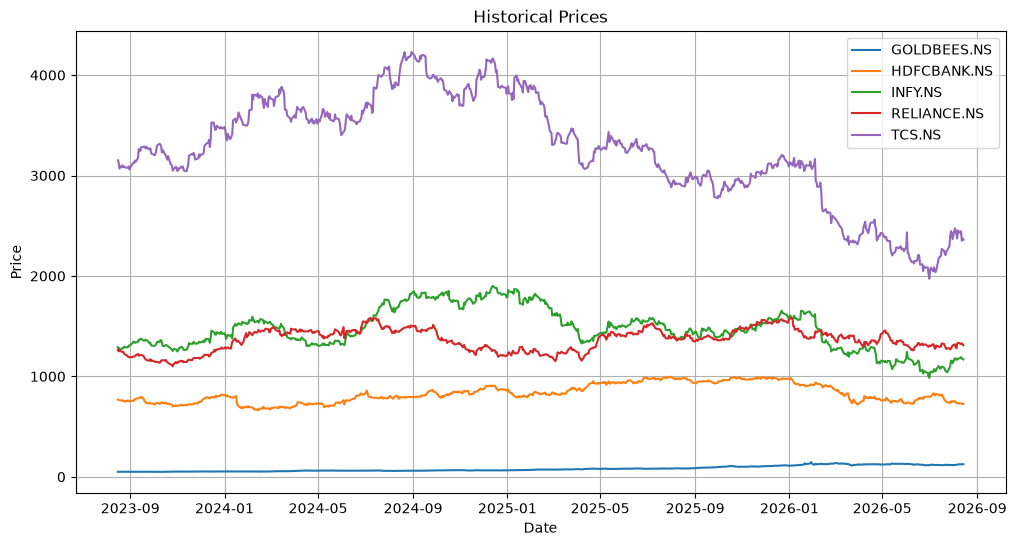

In [14]:
plt.figure(figsize=(12, 6))

for ticker in prices.columns:
    plt.plot(prices[ticker], label=ticker)

plt.title("Historical Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
returns.describe()

Ticker,GOLDBEES.NS,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
count,742.000000,742.000000,742.000000,742.000000,742.000000
mean,0.001332,0.000005,-0.000002,0.000131,-0.000283
std,0.013630,0.012702,0.016214,0.013162,0.014633
min,-0.105166,-0.084358,-0.072585,-0.074851,-0.083861
25%,-0.003711,-0.006511,-0.008617,-0.007958,-0.007611
50%,0.001266,-0.000014,-0.000598,0.000172,-0.000576
75%,0.006538,0.006747,0.007833,0.007117,0.006892
max,0.078854,0.057124,0.079340,0.070192,0.066328


In [16]:
mean_daily_return = returns.mean()
mean_daily_return

Ticker
GOLDBEES.NS    0.001332
HDFCBANK.NS    0.000005
INFY.NS       -0.000002
RELIANCE.NS    0.000131
TCS.NS        -0.000283
dtype: float64

In [17]:
annual_return = mean_daily_return*265
annual_return

Ticker
GOLDBEES.NS    0.352860
HDFCBANK.NS    0.001404
INFY.NS       -0.000505
RELIANCE.NS    0.034614
TCS.NS        -0.074868
dtype: float64

In [18]:
daily_volatility = returns.std()

daily_volatility

Ticker
GOLDBEES.NS    0.013630
HDFCBANK.NS    0.012702
INFY.NS        0.016214
RELIANCE.NS    0.013162
TCS.NS         0.014633
dtype: float64

In [19]:
annual_volatility = daily_volatility * np.sqrt(252)

annual_volatility

Ticker
GOLDBEES.NS    0.216365
HDFCBANK.NS    0.201642
INFY.NS        0.257382
RELIANCE.NS    0.208942
TCS.NS         0.232285
dtype: float64

In [20]:
risk_free_rate = 0.065

In [21]:
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

sharpe_ratio

Ticker
GOLDBEES.NS    1.330438
HDFCBANK.NS   -0.315390
INFY.NS       -0.254507
RELIANCE.NS   -0.145427
TCS.NS        -0.602141
dtype: float64

In [22]:
risk_return_table = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility,
    "Sharpe Ratio": sharpe_ratio
})

risk_return_table

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
GOLDBEES.NS,0.352860,0.216365,1.330438
HDFCBANK.NS,0.001404,0.201642,-0.315390
INFY.NS,-0.000505,0.257382,-0.254507
RELIANCE.NS,0.034614,0.208942,-0.145427
TCS.NS,-0.074868,0.232285,-0.602141


In [23]:
risk_return_table["Annual Return"] = risk_return_table["Annual Return"] * 100
risk_return_table["Annual Volatility"] = risk_return_table["Annual Volatility"] * 100

risk_return_table

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
GOLDBEES.NS,35.285984,21.636475,1.330438
HDFCBANK.NS,0.140394,20.164239,-0.315390
INFY.NS,-0.050541,25.738169,-0.254507
RELIANCE.NS,3.461417,20.894215,-0.145427
TCS.NS,-7.486839,23.228506,-0.602141


In [24]:
#nifty fifty data beta analysis 
nifty = yf.download(
    "^NSEI",
    start=start_date,
    end=end_date,
    auto_adjust=True
)

nifty.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2023-08-16,19465.000000,19482.750000,19317.199219,19369.000000,0
2023-08-17,19365.250000,19461.550781,19326.250000,19450.550781,268700
2023-08-18,19310.150391,19373.800781,19253.599609,19301.750000,256100
2023-08-21,19393.599609,19425.949219,19296.300781,19320.650391,262600
2023-08-22,19396.449219,19443.500000,19381.300781,19417.099609,208700


In [25]:
nifty_prices = nifty["Close"]

nifty_prices.head()

Ticker,^NSEI
Date,
2023-08-16,19465.000000
2023-08-17,19365.250000
2023-08-18,19310.150391
2023-08-21,19393.599609
2023-08-22,19396.449219


In [26]:
nifty_prices = nifty_prices.squeeze()

print(type(nifty_prices))

<class 'pandas.Series'>


In [27]:
nifty_returns = nifty_prices.pct_change().dropna()

nifty_returns.name = "NIFTY"

nifty_returns.head()

Date
2023-08-17   -0.005125
2023-08-18   -0.002845
2023-08-21    0.004322
2023-08-22    0.000147
2023-08-23    0.002452
Name: NIFTY, dtype: float64

In [28]:
combined_returns = returns.join(
    nifty_returns,
    how="inner"
)

combined_returns.head()

,GOLDBEES.NS,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS,NIFTY
Date,,,,,,
2023-08-17,-0.005787,-0.005541,-0.004899,-0.014426,-0.006549,-0.005125
2023-08-18,-0.001405,-0.004101,-0.016117,0.007407,-0.019981,-0.002845
2023-08-21,-0.001407,-0.000786,0.011953,-0.010911,0.010261,0.004322
2023-08-22,0.004428,-0.004278,-0.001174,-0.000238,-0.005733,0.000147
2023-08-23,-0.001804,0.002464,0.002992,0.001111,0.004760,0.002452


In [29]:
# calculation of Beta
def calculate_beta(asset_returns, market_returns):
    covariance = np.cov(asset_returns, market_returns)[0, 1]
    market_variance = np.var(market_returns)

    beta = covariance / market_variance

    return beta

In [30]:
betas = {}

for ticker in portfolio.keys():
    betas[ticker] = calculate_beta(
        combined_returns[ticker],
        combined_returns["NIFTY"]
    )

betas

{'RELIANCE.NS': np.float64(1.0868670087311145),
 'HDFCBANK.NS': np.float64(1.061066219852174),
 'TCS.NS': np.float64(0.7739186366901643),
 'INFY.NS': np.float64(0.870182204146627),
 'GOLDBEES.NS': np.float64(0.24035686666921352)}

In [31]:
risk_return_table["Beta"] = pd.Series(betas)
risk_return_table

,Annual Return,Annual Volatility,Sharpe Ratio,Beta
Ticker,,,,
GOLDBEES.NS,35.285984,21.636475,1.330438,0.240357
HDFCBANK.NS,0.140394,20.164239,-0.315390,1.061066
INFY.NS,-0.050541,25.738169,-0.254507,0.870182
RELIANCE.NS,3.461417,20.894215,-0.145427,1.086867
TCS.NS,-7.486839,23.228506,-0.602141,0.773919


In [32]:
#Correlation & Portfolio Risk
correlation_matrix = returns.corr()

correlation_matrix

Ticker,GOLDBEES.NS,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
GOLDBEES.NS,1.000000,0.141988,0.001912,0.044694,-0.006846
HDFCBANK.NS,0.141988,1.000000,0.170639,0.383311,0.156307
INFY.NS,0.001912,0.170639,1.000000,0.205999,0.749411
RELIANCE.NS,0.044694,0.383311,0.205999,1.000000,0.240998
TCS.NS,-0.006846,0.156307,0.749411,0.240998,1.000000


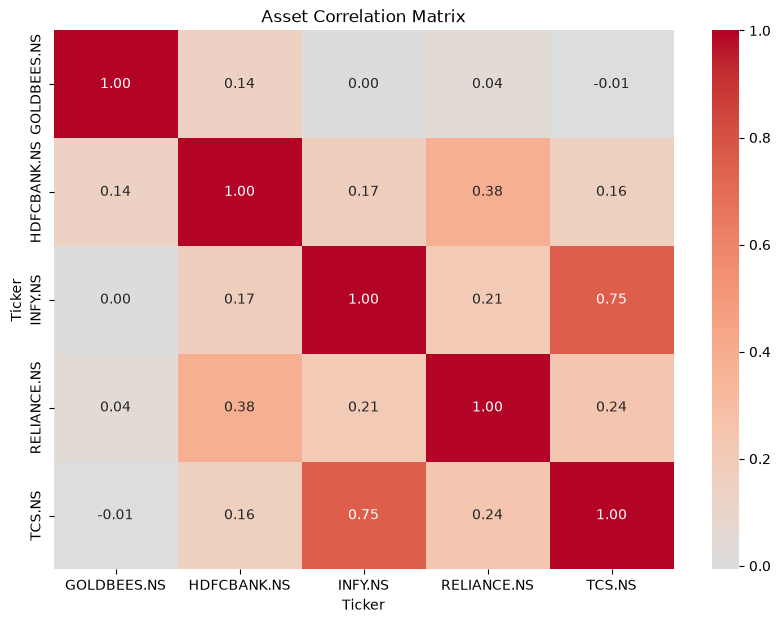

In [33]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Asset Correlation Matrix")
plt.show()

In [34]:
portfolio = {
    "RELIANCE.NS": 0.25,
    "HDFCBANK.NS": 0.25,
    "TCS.NS": 0.20,
    "INFY.NS": 0.15,
    "GOLDBEES.NS": 0.15
}

In [35]:
weights = np.array(list(portfolio.values()))

weights

array([0.25, 0.25, 0.2 , 0.15, 0.15])

In [36]:
weights.sum()

np.float64(1.0)

In [37]:
portfolio_return = np.dot(weights, annual_return)

portfolio_return

np.float64(0.0824267311290183)

In [38]:
portfolio_return * 100

np.float64(8.24267311290183)

In [39]:
covariance_matrix = returns.cov() * 252

covariance_matrix

Ticker,GOLDBEES.NS,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
GOLDBEES.NS,0.046814,0.006195,0.000106,0.002021,-0.000344
HDFCBANK.NS,0.006195,0.040660,0.008856,0.016149,0.007321
INFY.NS,0.000106,0.008856,0.066245,0.011078,0.044804
RELIANCE.NS,0.002021,0.016149,0.011078,0.043657,0.011697
TCS.NS,-0.000344,0.007321,0.044804,0.011697,0.053956


In [40]:
portfolio_variance = np.dot(
    weights.T,
    np.dot(covariance_matrix, weights)
)

portfolio_variance

np.float64(0.017749105976397117)

In [41]:
portfolio_volatility = np.sqrt(portfolio_variance)

portfolio_volatility

np.float64(0.13322577069169883)

In [42]:
portfolio_volatility * 100

np.float64(13.322577069169883)

In [43]:
portfolio_sharpe = (
    portfolio_return - risk_free_rate
) / portfolio_volatility

portfolio_sharpe

np.float64(0.13080600726526057)

In [44]:
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Portfolio Return",
        "Portfolio Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        portfolio_return,
        portfolio_volatility,
        portfolio_sharpe
    ]
})

portfolio_summary

,Metric,Value
0,Portfolio Return,0.082427
1,Portfolio Volatility,0.133226
2,Sharpe Ratio,0.130806


In [45]:
from scipy.optimize import minimize

In [46]:
# PORTFOLIO OPTIMIZE
def portfolio_performance(weights):
    
    portfolio_return = np.dot(weights, annual_return)
    
    portfolio_variance = np.dot(
        weights.T,
        np.dot(covariance_matrix, weights)
    )
    
    portfolio_volatility = np.sqrt(portfolio_variance)
    
    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    return portfolio_return, portfolio_volatility, sharpe_ratio

In [47]:
def negative_sharpe(weights):
    
    return -portfolio_performance(weights)[2]

In [48]:
constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

In [53]:
bounds = tuple(
    (0.10, 0.40) for _ in range(len(portfolio))
)

In [54]:
initial_weights = np.array(
    [1 / len(portfolio)] * len(portfolio)
)

initial_weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [55]:
optimization_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [56]:
print(optimization_result.success)

True


In [57]:
print(optimization_result.message)

Optimization terminated successfully


In [58]:
optimal_weights = optimization_result.x

optimal_portfolio = pd.DataFrame({
    "Asset": list(portfolio.keys()),
    "Optimal Weight": optimal_weights
})

optimal_portfolio

,Asset,Optimal Weight
0,RELIANCE.NS,0.4
1,HDFCBANK.NS,0.1
2,TCS.NS,0.1
3,INFY.NS,0.3
4,GOLDBEES.NS,0.1


In [59]:
optimal_portfolio["Optimal Weight"] = (
    optimal_portfolio["Optimal Weight"] * 100
)

optimal_portfolio

,Asset,Optimal Weight
0,RELIANCE.NS,40.0
1,HDFCBANK.NS,10.0
2,TCS.NS,10.0
3,INFY.NS,30.0
4,GOLDBEES.NS,10.0


In [60]:
print("Minimum weight:", optimal_weights.min())
print("Maximum weight:", optimal_weights.max())
print("Total weight:", optimal_weights.sum())

Minimum weight: 0.1000000000000005
Maximum weight: 0.3999999999999954
Total weight: 1.0


In [61]:
optimized_return, optimized_volatility, optimized_sharpe = (
    portfolio_performance(optimal_weights)
)

In [62]:
print("Optimized Portfolio")
print("----------------------------")
print(f"Expected Return: {optimized_return:.2%}")
print(f"Volatility:      {optimized_volatility:.2%}")
print(f"Sharpe Ratio:    {optimized_sharpe:.2f}")

Optimized Portfolio
----------------------------
Expected Return: 14.41%
Volatility:      13.25%
Sharpe Ratio:    0.60


In [63]:
comparison = pd.DataFrame({
    "Metric": [
        "Expected Return",
        "Volatility",
        "Sharpe Ratio"
    ],
    "Current Portfolio": [
        portfolio_return,
        portfolio_volatility,
        portfolio_sharpe
    ],
    "Optimized Portfolio": [
        optimized_return,
        optimized_volatility,
        optimized_sharpe
    ]
})

comparison

,Metric,Current Portfolio,Optimized Portfolio
0,Expected Return,0.082427,0.144131
1,Volatility,0.133226,0.132456
2,Sharpe Ratio,0.130806,0.597417


In [64]:
#Random portfolio 
def generate_random_portfolio():
    
    weights = np.random.random(len(portfolio))
    
    weights = weights / np.sum(weights)
    
    portfolio_return = np.dot(weights, annual_return)
    
    portfolio_variance = np.dot(
        weights.T,
        np.dot(covariance_matrix, weights)
    )
    
    portfolio_volatility = np.sqrt(portfolio_variance)
    
    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    return (
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio,
        weights
    )

In [65]:
num_portfolios = 5000

results = []

for _ in range(num_portfolios):
    
    results.append(
        generate_random_portfolio()
    )

In [66]:
frontier_data = pd.DataFrame(
    results,
    columns=[
        "Return",
        "Volatility",
        "Sharpe",
        "Weights"
    ]
)

frontier_data.head()

,Return,Volatility,Sharpe,Weights
0,0.095279,0.168093,0.180130,"[0.32041729182322126, 0.007601461078398286, 0...."
1,0.105609,0.132673,0.306086,"[0.2835869103635746, 0.3371952801710187, 0.175..."
2,0.135581,0.135554,0.520686,"[0.3807592989837908, 0.36661705467187267, 0.10..."
3,0.013381,0.166047,-0.310868,"[0.10811569675210377, 0.23909074422397844, 0.3..."
4,0.040799,0.157348,-0.153808,"[0.17972014522429108, 0.17467448932981583, 0.2..."


In [67]:
max_sharpe_index = frontier_data["Sharpe"].idxmax()

max_sharpe_random = frontier_data.loc[
    max_sharpe_index
]

max_sharpe_random

Return                                                 0.252114
Volatility                                             0.162187
Sharpe                                                 1.153695
Weights       [0.6976233493759589, 0.03212475720077967, 0.05...
Name: 611, dtype: object

In [68]:
min_volatility_index = frontier_data["Volatility"].idxmin()

min_volatility_random = frontier_data.loc[
    min_volatility_index
]

min_volatility_random

Return                                                 0.100144
Volatility                                             0.128729
Sharpe                                                  0.27301
Weights       [0.3034956162202104, 0.2157889060295234, 0.057...
Name: 4783, dtype: object

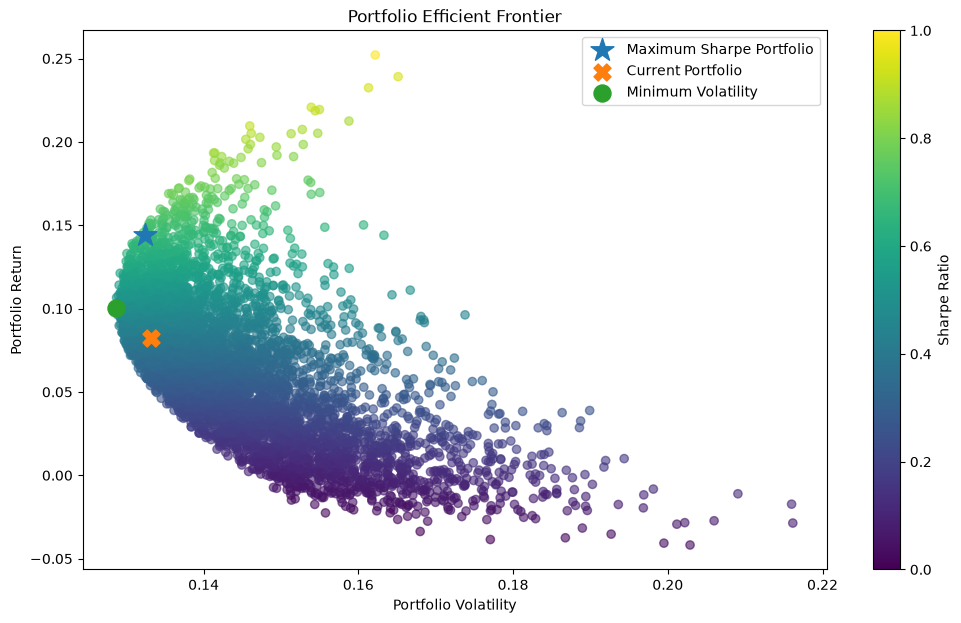

In [69]:
plt.figure(figsize=(12, 7))

plt.scatter(
    frontier_data["Volatility"],
    frontier_data["Return"],
    c=frontier_data["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.scatter(
    optimized_volatility,
    optimized_return,
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

plt.scatter(
    portfolio_volatility,
    portfolio_return,
    marker="X",
    s=150,
    label="Current Portfolio"
)

plt.scatter(
    min_volatility_random["Volatility"],
    min_volatility_random["Return"],
    marker="o",
    s=150,
    label="Minimum Volatility"
)

plt.xlabel("Portfolio Volatility")
plt.ylabel("Portfolio Return")
plt.title("Portfolio Efficient Frontier")

plt.colorbar(label="Sharpe Ratio")

plt.legend()

plt.show()

In [70]:
#Generate constrained random portfolios
def generate_constrained_portfolio():
    
    while True:
        weights = np.random.dirichlet(
            np.ones(len(portfolio))
        )
        
        # Scale weights so every asset gets at least 10%
        weights = 0.10 + 0.50 * weights
        
        # Check maximum allocation constraint
        if np.all(weights <= 0.40):
            return weights

In [71]:
num_portfolios = 5000

results = []

for _ in range(num_portfolios):
    
    weights = generate_constrained_portfolio()
    
    portfolio_return = np.dot(
        weights,
        annual_return
    )
    
    portfolio_variance = np.dot(
        weights.T,
        np.dot(covariance_matrix, weights)
    )
    
    portfolio_volatility = np.sqrt(
        portfolio_variance
    )
    
    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    results.append([
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio,
        weights
    ])

In [72]:
frontier_data = pd.DataFrame(
    results,
    columns=[
        "Return",
        "Volatility",
        "Sharpe",
        "Weights"
    ]
)

frontier_data.head()

,Return,Volatility,Sharpe,Weights
0,0.112230,0.130200,0.362747,"[0.3365765900628386, 0.17210835917023098, 0.13..."
1,0.054832,0.136148,-0.074683,"[0.16124996153299032, 0.3435661273572811, 0.17..."
2,0.034075,0.140416,-0.220237,"[0.10502795768815316, 0.31675253285847116, 0.1..."
3,0.041787,0.150464,-0.154278,"[0.1299701792973367, 0.23630550397317016, 0.35..."
4,0.105573,0.130169,0.311696,"[0.3254020222538223, 0.2591431108487684, 0.105..."


In [73]:
max_sharpe_index = frontier_data["Sharpe"].idxmax()

max_sharpe_random = frontier_data.loc[
    max_sharpe_index
]

max_sharpe_random

Return                                                 0.140453
Volatility                                             0.130808
Sharpe                                                 0.576822
Weights       [0.3998545551669258, 0.1902405543471653, 0.113...
Name: 1214, dtype: object

In [74]:
min_volatility_index = frontier_data["Volatility"].idxmin()

min_volatility_random = frontier_data.loc[
    min_volatility_index
]

min_volatility_random

Return                                                 0.103672
Volatility                                             0.129137
Sharpe                                                 0.299466
Weights       [0.30816553355811355, 0.23806633252719636, 0.1...
Name: 2936, dtype: object

In [75]:
print("Minimum weight in simulation:")
print(min(
    min(w) for w in frontier_data["Weights"]
))

print("\nMaximum weight in simulation:")
print(max(
    max(w) for w in frontier_data["Weights"]
))

Minimum weight in simulation:
0.10001881885609765

Maximum weight in simulation:
0.399933043965513


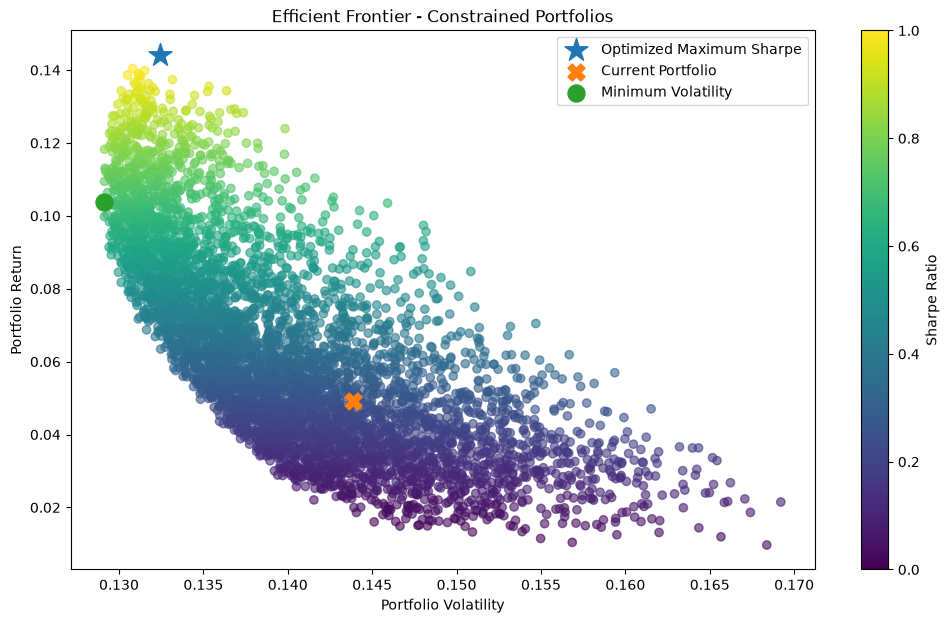

In [76]:
plt.figure(figsize=(12, 7))

plt.scatter(
    frontier_data["Volatility"],
    frontier_data["Return"],
    c=frontier_data["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

# Optimized portfolio
plt.scatter(
    optimized_volatility,
    optimized_return,
    marker="*",
    s=300,
    label="Optimized Maximum Sharpe"
)

# Current portfolio
plt.scatter(
    portfolio_volatility,
    portfolio_return,
    marker="X",
    s=150,
    label="Current Portfolio"
)

# Minimum volatility
plt.scatter(
    min_volatility_random["Volatility"],
    min_volatility_random["Return"],
    marker="o",
    s=150,
    label="Minimum Volatility"
)

plt.xlabel("Portfolio Volatility")
plt.ylabel("Portfolio Return")
plt.title(
    "Efficient Frontier - Constrained Portfolios"
)

plt.colorbar(label="Sharpe Ratio")

plt.legend()

plt.show()

In [77]:
#Calculate optimized portfolio daily returns
optimized_daily_returns = returns.dot(optimal_weights)

optimized_daily_returns.head()

Date
2023-08-17   -0.008342
2023-08-18   -0.002360
2023-08-21   -0.001693
2023-08-22    0.000581
2023-08-23    0.000634
dtype: float64

In [78]:
initial_investment = 100000

portfolio_value = (
    1 + optimized_daily_returns
).cumprod() * initial_investment

portfolio_value.head()

Date
2023-08-17    99165.821647
2023-08-18    98931.822274
2023-08-21    98764.285098
2023-08-22    98821.712272
2023-08-23    98884.327934
dtype: float64

In [79]:
running_peak = portfolio_value.cummax()

running_peak.head()

Date
2023-08-17    99165.821647
2023-08-18    99165.821647
2023-08-21    99165.821647
2023-08-22    99165.821647
2023-08-23    99165.821647
dtype: float64

In [80]:
drawdown = (
    portfolio_value - running_peak
) / running_peak

drawdown.head()

Date
2023-08-17    0.000000
2023-08-18   -0.002360
2023-08-21   -0.004049
2023-08-22   -0.003470
2023-08-23   -0.002839
dtype: float64

In [81]:
maximum_drawdown = drawdown.min()

print(f"Maximum Drawdown: {maximum_drawdown:.2%}")

Maximum Drawdown: -18.86%


In [82]:
max_drawdown_date = drawdown.idxmin()

print("Maximum Drawdown Date:", max_drawdown_date)

Maximum Drawdown Date: 2026-07-01 00:00:00


In [83]:
trough_value = portfolio_value.loc[max_drawdown_date]

print(f"Trough Value: ₹{trough_value:,.2f}")

Trough Value: ₹137,096.62


In [84]:
peak_date = portfolio_value.loc[
    :max_drawdown_date
].idxmax()

peak_value = portfolio_value.loc[peak_date]

print("Peak Date:", peak_date)
print(f"Peak Value: ₹{peak_value:,.2f}")

Peak Date: 2026-01-29 00:00:00
Peak Value: ₹168,965.47


In [85]:
recovery_data = portfolio_value.loc[max_drawdown_date:]

recovery_dates = recovery_data[
    recovery_data >= peak_value
]

if len(recovery_dates) > 0:
    recovery_date = recovery_dates.index[0]
    
    recovery_days = (
        recovery_date - peak_date
    ).days
    
    print("Recovery Date:", recovery_date)
    print("Recovery Time:", recovery_days, "days")
else:
    print("Portfolio has not recovered from the maximum drawdown yet.")

Portfolio has not recovered from the maximum drawdown yet.


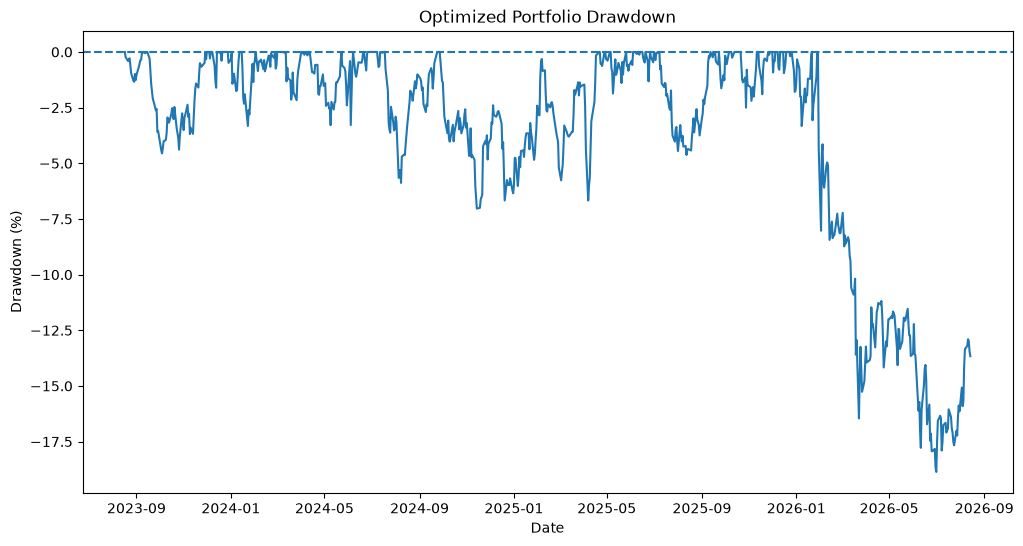

In [86]:
plt.figure(figsize=(12, 6))

plt.plot(
    drawdown.index,
    drawdown * 100
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.title("Optimized Portfolio Drawdown")

plt.show()

In [87]:
optimized_daily_returns.describe()

count    742.000000
mean       0.000544
std        0.008344
min       -0.043552
25%       -0.003415
50%        0.000644
75%        0.005107
max        0.037696
dtype: float64

In [88]:
var_95 = optimized_daily_returns.quantile(0.05)

print(f"95% Daily VaR: {var_95:.2%}")

95% Daily VaR: -1.30%


In [89]:
portfolio_value_initial = 100000

var_95_rupees = (
    abs(var_95) * portfolio_value_initial
)

print(f"95% Daily VaR: ₹{var_95_rupees:,.2f}")

95% Daily VaR: ₹1,304.91


In [90]:
worst_returns = optimized_daily_returns[
    optimized_daily_returns <= var_95
]

expected_shortfall_95 = worst_returns.mean()

print(
    f"95% Expected Shortfall: "
    f"{expected_shortfall_95:.2%}"
)

95% Expected Shortfall: -1.97%


In [91]:
es_95_rupees = (
    abs(expected_shortfall_95)
    * portfolio_value_initial
)

print(
    f"95% Expected Shortfall: "
    f"₹{es_95_rupees:,.2f}"
)

95% Expected Shortfall: ₹1,968.46


In [92]:
risk_summary = pd.DataFrame({
    "Risk Metric": [
        "Maximum Drawdown",
        "95% Daily VaR",
        "95% Expected Shortfall"
    ],
    "Percentage": [
        maximum_drawdown,
        var_95,
        expected_shortfall_95
    ]
})

risk_summary

,Risk Metric,Percentage
0,Maximum Drawdown,-0.188612
1,95% Daily VaR,-0.013049
2,95% Expected Shortfall,-0.019685


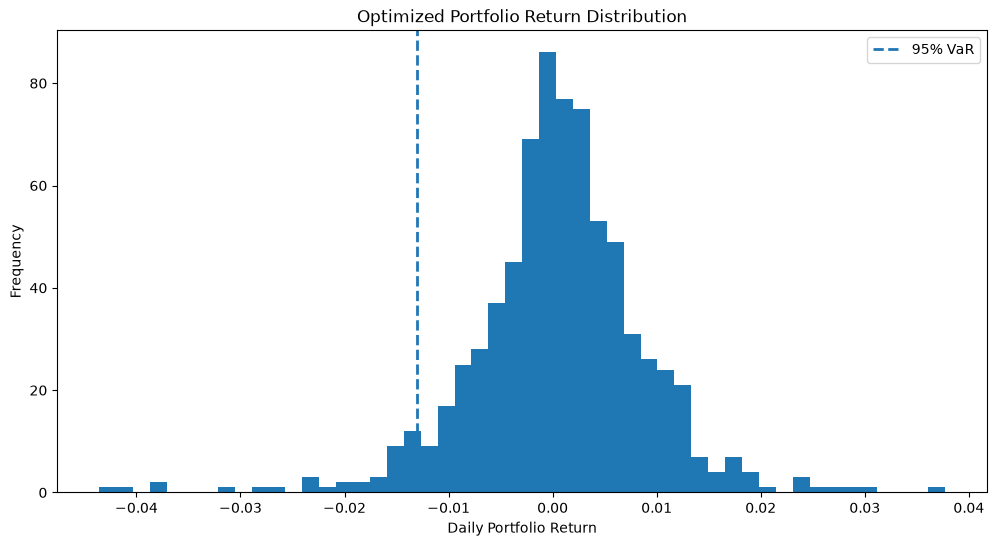

In [93]:
plt.figure(figsize=(12, 6))

plt.hist(
    optimized_daily_returns,
    bins=50
)

plt.axvline(
    var_95,
    linestyle="--",
    linewidth=2,
    label="95% VaR"
)

plt.xlabel("Daily Portfolio Return")
plt.ylabel("Frequency")
plt.title("Optimized Portfolio Return Distribution")

plt.legend()

plt.show()

In [94]:
#14
stress_weights = pd.DataFrame({
    "Asset": list(portfolio.keys()),
    "Weight": optimal_weights
})

stress_weights

,Asset,Weight
0,RELIANCE.NS,0.4
1,HDFCBANK.NS,0.1
2,TCS.NS,0.1
3,INFY.NS,0.3
4,GOLDBEES.NS,0.1


In [95]:
stress_scenarios = {
    "Market Crash": {
        "RELIANCE.NS": -0.20,
        "HDFCBANK.NS": -0.20,
        "TCS.NS": -0.20,
        "INFY.NS": -0.20,
        "GOLDBEES.NS": 0.00
    },
    
    "Bull Market": {
        "RELIANCE.NS": 0.20,
        "HDFCBANK.NS": 0.20,
        "TCS.NS": 0.20,
        "INFY.NS": 0.20,
        "GOLDBEES.NS": 0.00
    },
    
    "Crash + Gold Hedge": {
        "RELIANCE.NS": -0.20,
        "HDFCBANK.NS": -0.20,
        "TCS.NS": -0.20,
        "INFY.NS": -0.20,
        "GOLDBEES.NS": 0.10
    }
}

In [96]:
stress_results = []

for scenario, asset_returns in stress_scenarios.items():
    
    scenario_return = 0
    
    for asset in portfolio.keys():
        
        scenario_return += (
            portfolio[asset]
            * asset_returns[asset]
        )
    
    stress_results.append([
        scenario,
        scenario_return
    ])

In [97]:
stress_results_df = pd.DataFrame(
    stress_results,
    columns=[
        "Scenario",
        "Portfolio Impact"
    ]
)

stress_results_df

,Scenario,Portfolio Impact
0,Market Crash,-0.170
1,Bull Market,0.170
2,Crash + Gold Hedge,-0.155


In [98]:
stress_investment = 1000000

stress_results_df["Impact (₹)"] = (
    stress_results_df["Portfolio Impact"]
    * stress_investment
)

stress_results_df

,Scenario,Portfolio Impact,Impact (₹)
0,Market Crash,-0.170,-170000.0
1,Bull Market,0.170,170000.0
2,Crash + Gold Hedge,-0.155,-155000.0


In [99]:
stress_results_df["Portfolio Value After Scenario"] = (
    stress_investment
    + stress_results_df["Impact (₹)"]
)

stress_results_df

,Scenario,Portfolio Impact,Impact (₹),Portfolio Value After Scenario
0,Market Crash,-0.170,-170000.0,830000.0
1,Bull Market,0.170,170000.0,1170000.0
2,Crash + Gold Hedge,-0.155,-155000.0,845000.0


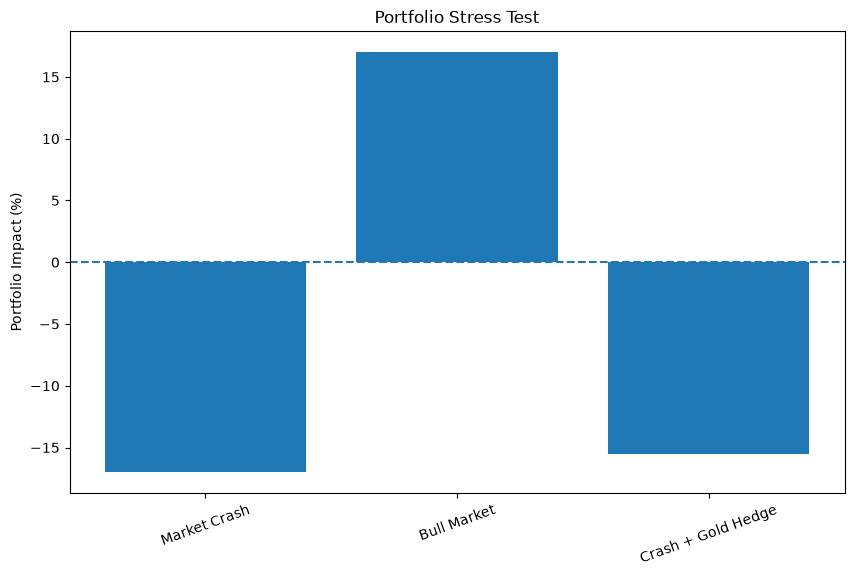

In [100]:
plt.figure(figsize=(10, 6))

plt.bar(
    stress_results_df["Scenario"],
    stress_results_df["Portfolio Impact"] * 100
)

plt.axhline(
    0,
    linestyle="--"
)

plt.ylabel("Portfolio Impact (%)")
plt.title("Portfolio Stress Test")

plt.xticks(rotation=20)

plt.show()

In [101]:
severe_crash = {
    "RELIANCE.NS": -0.30,
    "HDFCBANK.NS": -0.25,
    "TCS.NS": -0.20,
    "INFY.NS": -0.25,
    "GOLDBEES.NS": 0.10
}

In [102]:
severe_crash_impact = sum(
    portfolio[asset] * severe_crash[asset]
    for asset in portfolio.keys()
)

print(
    f"Severe Crash Portfolio Impact: "
    f"{severe_crash_impact:.2%}"
)

Severe Crash Portfolio Impact: -20.00%


In [103]:
severe_crash_value = (
    stress_investment
    * (1 + severe_crash_impact)
)

print(
    f"Portfolio Value After Severe Crash: "
    f"₹{severe_crash_value:,.2f}"
)

Portfolio Value After Severe Crash: ₹800,000.00


In [104]:
#Download Nifty 50 data
benchmark = yf.download(
    "^NSEI",
    start=returns.index.min(),
    end=returns.index.max(),
    auto_adjust=True,
    progress=False
)

benchmark.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2023-08-17,19365.250000,19461.550781,19326.250000,19450.550781,268700
2023-08-18,19310.150391,19373.800781,19253.599609,19301.750000,256100
2023-08-21,19393.599609,19425.949219,19296.300781,19320.650391,262600
2023-08-22,19396.449219,19443.500000,19381.300781,19417.099609,208700
2023-08-23,19444.000000,19472.050781,19366.599609,19439.199219,225200


In [105]:
benchmark_prices = benchmark["Close"]

benchmark_prices.head()

Ticker,^NSEI
Date,
2023-08-17,19365.250000
2023-08-18,19310.150391
2023-08-21,19393.599609
2023-08-22,19396.449219
2023-08-23,19444.000000


In [106]:
benchmark_prices = benchmark["Close"].squeeze()

In [107]:
benchmark_returns = benchmark_prices.pct_change().dropna()

benchmark_returns.head()

Date
2023-08-18   -0.002845
2023-08-21    0.004322
2023-08-22    0.000147
2023-08-23    0.002452
2023-08-24   -0.002947
Name: ^NSEI, dtype: float64

In [108]:
comparison = pd.concat(
    [
        optimized_daily_returns,
        benchmark_returns
    ],
    axis=1,
    join="inner"
)

comparison.columns = [
    "Portfolio",
    "NIFTY50"
]

comparison.head()

,Portfolio,NIFTY50
Date,,
2023-08-18,-0.002360,-0.002845
2023-08-21,-0.001693,0.004322
2023-08-22,0.000581,0.000147
2023-08-23,0.000634,0.002452
2023-08-24,-0.002934,-0.002947


In [109]:
portfolio_annual_return = (
    comparison["Portfolio"].mean() * 252
)

nifty_annual_return = (
    comparison["NIFTY50"].mean() * 252
)

print(
    f"Portfolio Annualized Return: "
    f"{portfolio_annual_return:.2%}"
)

print(
    f"NIFTY 50 Annualized Return: "
    f"{nifty_annual_return:.2%}"
)

Portfolio Annualized Return: 14.19%
NIFTY 50 Annualized Return: 8.79%


In [110]:
portfolio_annual_volatility = (
    comparison["Portfolio"].std() * np.sqrt(252)
)

nifty_annual_volatility = (
    comparison["NIFTY50"].std() * np.sqrt(252)
)

print(
    f"Portfolio Volatility: "
    f"{portfolio_annual_volatility:.2%}"
)

print(
    f"NIFTY 50 Volatility: "
    f"{nifty_annual_volatility:.2%}"
)

Portfolio Volatility: 13.29%
NIFTY 50 Volatility: 13.25%


In [111]:
beta = (
    comparison["Portfolio"].cov(
        comparison["NIFTY50"]
    )
    /
    comparison["NIFTY50"].var()
)

print(f"Portfolio Beta: {beta:.2f}")

Portfolio Beta: 0.69


In [112]:
alpha = (
    portfolio_annual_return
    -
    (
        risk_free_rate
        +
        beta
        * (
            nifty_annual_return
            - risk_free_rate
        )
    )
)

print(f"Portfolio Alpha: {alpha:.2%}")

Portfolio Alpha: 6.11%


In [113]:
initial_value = 100000

comparison_growth = (
    1 + comparison
).cumprod() * initial_value

comparison_growth.head()

,Portfolio,NIFTY50
Date,,
2023-08-18,99764.032235,99715.471737
2023-08-21,99595.085744,100146.394234
2023-08-22,99652.995993,100161.109300
2023-08-23,99716.138375,100406.656253
2023-08-24,99423.564025,100110.761383


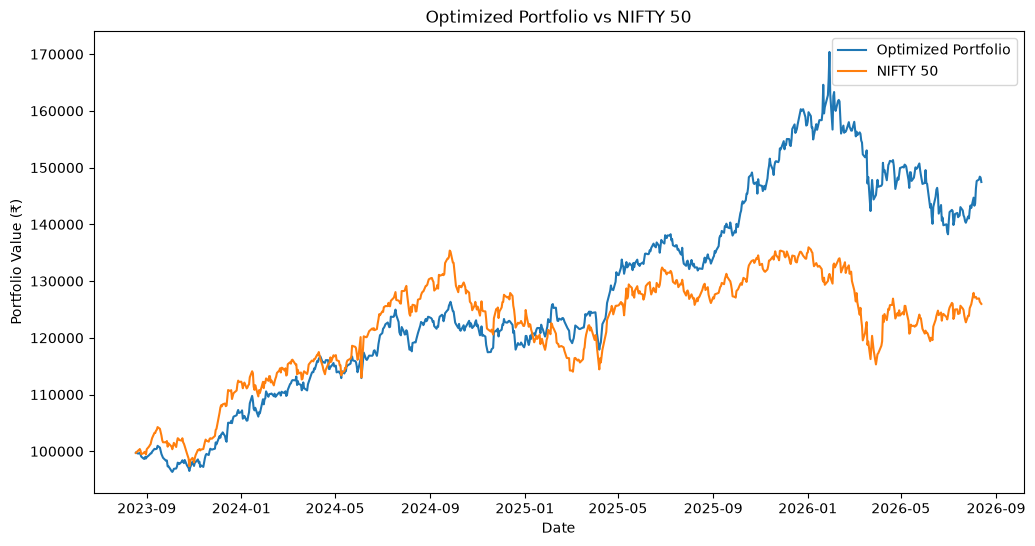

In [114]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison_growth.index,
    comparison_growth["Portfolio"],
    label="Optimized Portfolio"
)

plt.plot(
    comparison_growth.index,
    comparison_growth["NIFTY50"],
    label="NIFTY 50"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.title("Optimized Portfolio vs NIFTY 50")

plt.legend()

plt.show()

In [115]:
active_return = (
    portfolio_annual_return
    - nifty_annual_return
)

print(
    f"Active Return: {active_return:.2%}"
)

Active Return: 5.40%


In [116]:
performance_summary = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Beta",
        "Alpha",
        "Active Return"
    ],
    
    "Optimized Portfolio": [
        portfolio_annual_return,
        portfolio_annual_volatility,
        beta,
        alpha,
        active_return
    ],
    
    "NIFTY 50": [
        nifty_annual_return,
        nifty_annual_volatility,
        1,
        0,
        0
    ]
})

performance_summary

,Metric,Optimized Portfolio,NIFTY 50
0,Annualized Return,0.141856,0.087867
1,Annualized Volatility,0.132880,0.132519
2,Beta,0.691178,1.000000
3,Alpha,0.061051,0.000000
4,Active Return,0.053989,0.000000


In [117]:
#Dashboard
dashboard_metrics = pd.DataFrame({
    "Metric": [
        "Expected Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Beta",
        "Alpha",
        "Maximum Drawdown",
        "95% Daily VaR",
        "95% Expected Shortfall"
    ],
    
    "Value": [
        optimized_return,
        optimized_volatility,
        optimized_sharpe,
        beta,
        alpha,
        maximum_drawdown,
        var_95,
        expected_shortfall_95
    ]
})

dashboard_metrics

,Metric,Value
0,Expected Annual Return,0.144131
1,Annual Volatility,0.132456
2,Sharpe Ratio,0.597417
3,Beta,0.691178
4,Alpha,0.061051
5,Maximum Drawdown,-0.188612
6,95% Daily VaR,-0.013049
7,95% Expected Shortfall,-0.019685


In [118]:
allocation_table = pd.DataFrame({
    "Asset": list(portfolio.keys()),
    "Optimal Weight (%)": optimal_weights * 100
})

allocation_table

,Asset,Optimal Weight (%)
0,RELIANCE.NS,40.0
1,HDFCBANK.NS,10.0
2,TCS.NS,10.0
3,INFY.NS,30.0
4,GOLDBEES.NS,10.0


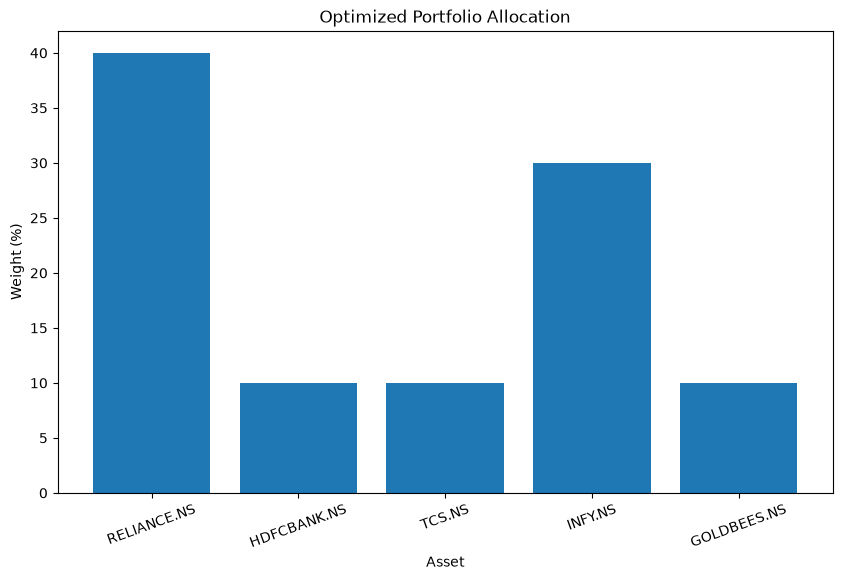

In [119]:
plt.figure(figsize=(10, 6))

plt.bar(
    allocation_table["Asset"],
    allocation_table["Optimal Weight (%)"]
)

plt.xlabel("Asset")
plt.ylabel("Weight (%)")
plt.title("Optimized Portfolio Allocation")

plt.xticks(rotation=20)

plt.show()

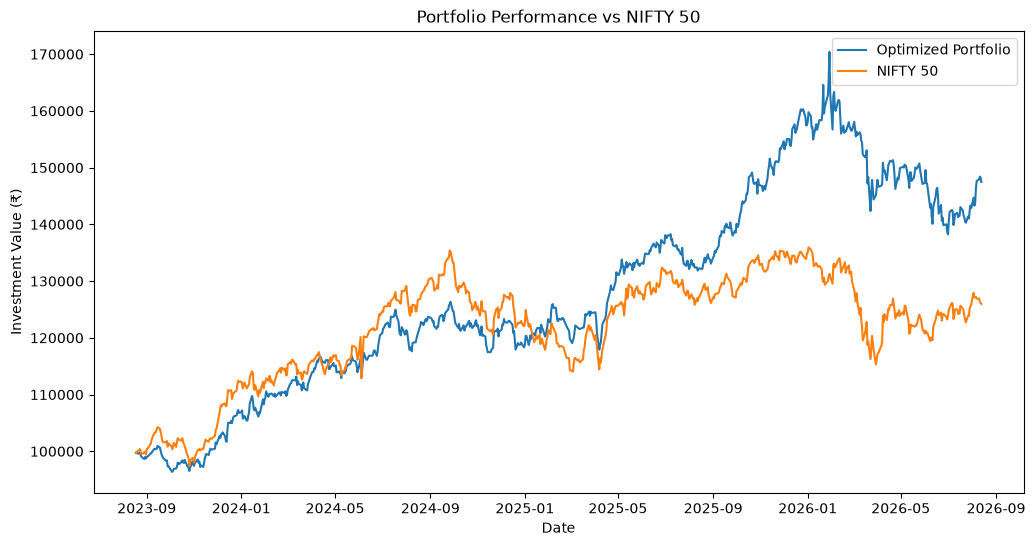

In [120]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison_growth.index,
    comparison_growth["Portfolio"],
    label="Optimized Portfolio"
)

plt.plot(
    comparison_growth.index,
    comparison_growth["NIFTY50"],
    label="NIFTY 50"
)

plt.xlabel("Date")
plt.ylabel("Investment Value (₹)")
plt.title("Portfolio Performance vs NIFTY 50")

plt.legend()

plt.show()

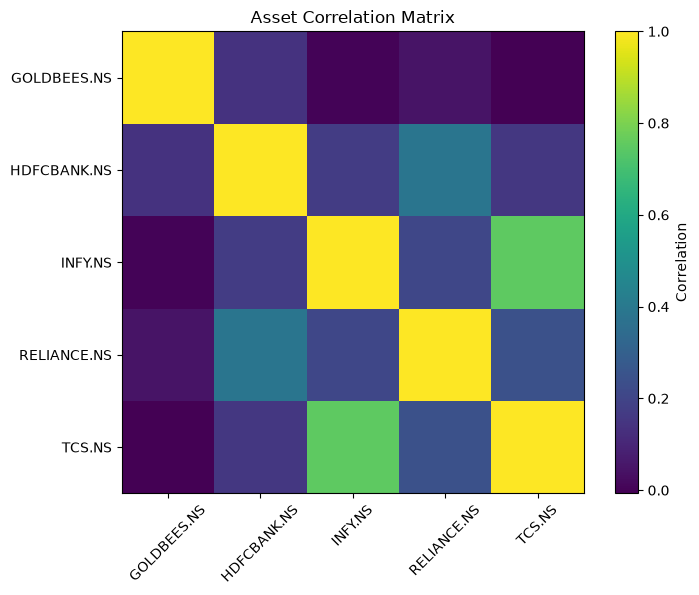

In [121]:
plt.figure(figsize=(8, 6))

plt.imshow(
    returns.corr(),
    cmap="viridis",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(returns.columns)),
    returns.columns,
    rotation=45
)

plt.yticks(
    range(len(returns.columns)),
    returns.columns
)

plt.title("Asset Correlation Matrix")

plt.show()

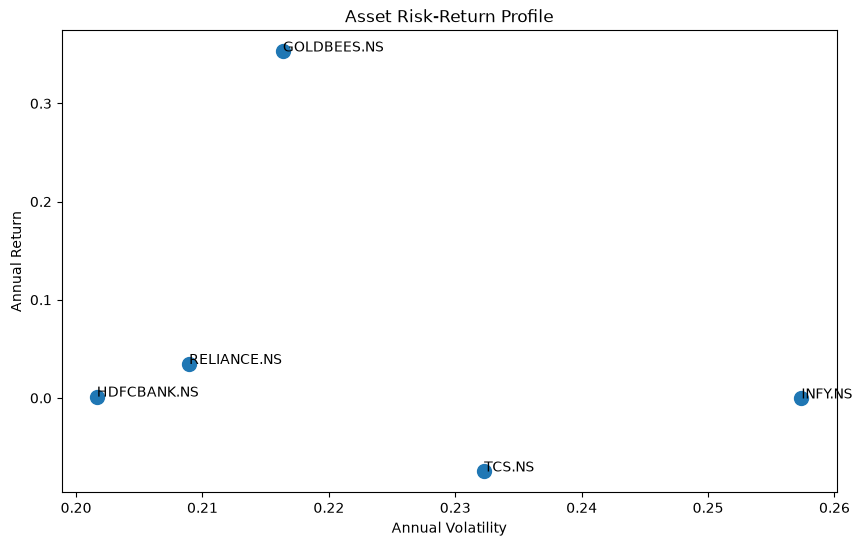

In [122]:
asset_risk_return = pd.DataFrame({
    "Return": annual_return,
    "Volatility": annual_volatility
})

plt.figure(figsize=(10, 6))

plt.scatter(
    asset_risk_return["Volatility"],
    asset_risk_return["Return"],
    s=100
)

for asset in asset_risk_return.index:
    
    plt.annotate(
        asset,
        (
            asset_risk_return.loc[asset, "Volatility"],
            asset_risk_return.loc[asset, "Return"]
        )
    )

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Asset Risk-Return Profile")

plt.show()

In [123]:
print("=" * 60)
print("        PORTFOLIO ANALYTICS DASHBOARD")
print("=" * 60)

print("\nPORTFOLIO PERFORMANCE")
print("-" * 60)

print(f"Expected Return       : {optimized_return:.2%}")
print(f"Volatility            : {optimized_volatility:.2%}")
print(f"Sharpe Ratio          : {optimized_sharpe:.2f}")

print("\nRISK METRICS")
print("-" * 60)

print(f"Beta                  : {beta:.2f}")
print(f"Alpha                 : {alpha:.2%}")
print(f"Maximum Drawdown      : {maximum_drawdown:.2%}")
print(f"95% Daily VaR         : {var_95:.2%}")
print(f"95% Expected Shortfall: {expected_shortfall_95:.2%}")

print("\nOPTIMAL ALLOCATION")
print("-" * 60)

for asset, weight in zip(
    portfolio.keys(),
    optimal_weights
):
    print(
        f"{asset:<15}: {weight:.2%}"
    )

print("\nBENCHMARK COMPARISON")
print("-" * 60)

print(
    f"Portfolio Return     : "
    f"{portfolio_annual_return:.2%}"
)

print(
    f"NIFTY 50 Return      : "
    f"{nifty_annual_return:.2%}"
)

print(
    f"Active Return        : "
    f"{active_return:.2%}"
)

print("=" * 60)

        PORTFOLIO ANALYTICS DASHBOARD

PORTFOLIO PERFORMANCE
------------------------------------------------------------
Expected Return       : 14.41%
Volatility            : 13.25%
Sharpe Ratio          : 0.60

RISK METRICS
------------------------------------------------------------
Beta                  : 0.69
Alpha                 : 6.11%
Maximum Drawdown      : -18.86%
95% Daily VaR         : -1.30%
95% Expected Shortfall: -1.97%

OPTIMAL ALLOCATION
------------------------------------------------------------
RELIANCE.NS    : 40.00%
HDFCBANK.NS    : 10.00%
TCS.NS         : 10.00%
INFY.NS        : 30.00%
GOLDBEES.NS    : 10.00%

BENCHMARK COMPARISON
------------------------------------------------------------
Portfolio Return     : 14.19%
NIFTY 50 Return      : 8.79%
Active Return        : 5.40%


In [124]:
#portfolio assessment
def assess_portfolio():
    
    assessment = []
    
    # Sharpe Ratio
    if optimized_sharpe >= 1:
        assessment.append(
            "The portfolio has a strong risk-adjusted return."
        )
    elif optimized_sharpe >= 0.5:
        assessment.append(
            "The portfolio has a moderate risk-adjusted return."
        )
    else:
        assessment.append(
            "The portfolio has a relatively weak risk-adjusted return."
        )
    
    # Alpha
    if alpha > 0:
        assessment.append(
            f"The portfolio generated positive alpha of {alpha:.2%} "
            "relative to the benchmark."
        )
    else:
        assessment.append(
            f"The portfolio generated negative alpha of {alpha:.2%} "
            "relative to the benchmark."
        )
    
    # Beta
    if beta < 0.8:
        assessment.append(
            "The portfolio has relatively low sensitivity to market movements."
        )
    elif beta <= 1.2:
        assessment.append(
            "The portfolio has moderate sensitivity to market movements."
        )
    else:
        assessment.append(
            "The portfolio has relatively high sensitivity to market movements."
        )
    
    # Maximum Drawdown
    if abs(maximum_drawdown) <= 0.10:
        assessment.append(
            "Historical maximum drawdown has been relatively low."
        )
    elif abs(maximum_drawdown) <= 0.20:
        assessment.append(
            "The portfolio experienced a moderate historical drawdown."
        )
    else:
        assessment.append(
            "The portfolio experienced a significant historical drawdown."
        )
    
    # Active Return
    if active_return > 0:
        assessment.append(
            "The portfolio outperformed the NIFTY 50 over the analyzed period."
        )
    else:
        assessment.append(
            "The portfolio underperformed the NIFTY 50 over the analyzed period."
        )
    
    return assessment

In [125]:
portfolio_assessment = assess_portfolio()

for point in portfolio_assessment:
    print("•", point)

• The portfolio has a moderate risk-adjusted return.
• The portfolio generated positive alpha of 6.11% relative to the benchmark.
• The portfolio has relatively low sensitivity to market movements.
• The portfolio experienced a moderate historical drawdown.
• The portfolio outperformed the NIFTY 50 over the analyzed period.


In [126]:
score = 0

# Sharpe
if optimized_sharpe >= 1:
    score += 2
elif optimized_sharpe >= 0.5:
    score += 1

# Alpha
if alpha > 0:
    score += 2

# Active return
if active_return > 0:
    score += 2

# Drawdown
if abs(maximum_drawdown) <= 0.10:
    score += 2
elif abs(maximum_drawdown) <= 0.20:
    score += 1

# Beta
if beta <= 1.2:
    score += 1

# VaR
if abs(var_95) <= 0.02:
    score += 1

print("Portfolio Score:", score, "/ 10")

Portfolio Score: 8 / 10


In [127]:
if score >= 8:
    rating = "STRONG"
elif score >= 6:
    rating = "MODERATE"
elif score >= 4:
    rating = "CAUTIOUS"
else:
    rating = "WEAK"

print("Overall Portfolio Rating:", rating)

Overall Portfolio Rating: STRONG


In [128]:
print("=" * 70)
print("              AUTOMATED PORTFOLIO REPORT")
print("=" * 70)

print("\nPORTFOLIO PERFORMANCE")
print("-" * 70)

print(f"Expected Annual Return : {optimized_return:.2%}")
print(f"Annual Volatility      : {optimized_volatility:.2%}")
print(f"Sharpe Ratio           : {optimized_sharpe:.2f}")

print("\nRISK ANALYSIS")
print("-" * 70)

print(f"Beta                   : {beta:.2f}")
print(f"Alpha                  : {alpha:.2%}")
print(f"Maximum Drawdown       : {maximum_drawdown:.2%}")
print(f"95% Daily VaR          : {var_95:.2%}")
print(f"95% Expected Shortfall : {expected_shortfall_95:.2%}")

print("\nBENCHMARK PERFORMANCE")
print("-" * 70)

print(f"Portfolio Return       : {portfolio_annual_return:.2%}")
print(f"NIFTY 50 Return        : {nifty_annual_return:.2%}")
print(f"Active Return          : {active_return:.2%}")

print("\nOPTIMAL ALLOCATION")
print("-" * 70)

for asset, weight in zip(
    portfolio.keys(),
    optimal_weights
):
    print(f"{asset:<20} : {weight:.2%}")

print("\nMODEL-BASED ASSESSMENT")
print("-" * 70)

for point in portfolio_assessment:
    print("•", point)

print("\nOVERALL ASSESSMENT")
print("-" * 70)

print(f"Score  : {score}/10")
print(f"Rating : {rating}")

print("=" * 70)

              AUTOMATED PORTFOLIO REPORT

PORTFOLIO PERFORMANCE
----------------------------------------------------------------------
Expected Annual Return : 14.41%
Annual Volatility      : 13.25%
Sharpe Ratio           : 0.60

RISK ANALYSIS
----------------------------------------------------------------------
Beta                   : 0.69
Alpha                  : 6.11%
Maximum Drawdown       : -18.86%
95% Daily VaR          : -1.30%
95% Expected Shortfall : -1.97%

BENCHMARK PERFORMANCE
----------------------------------------------------------------------
Portfolio Return       : 14.19%
NIFTY 50 Return        : 8.79%
Active Return          : 5.40%

OPTIMAL ALLOCATION
----------------------------------------------------------------------
RELIANCE.NS          : 40.00%
HDFCBANK.NS          : 10.00%
TCS.NS               : 10.00%
INFY.NS              : 30.00%
GOLDBEES.NS          : 10.00%

MODEL-BASED ASSESSMENT
----------------------------------------------------------------------
• T

In [132]:
print(
    "\nDisclaimer: This analysis is based on historical market data "
    "and model assumptions. Historical performance does not guarantee "
    "future results. The output is intended for analytical and "
    "educational purposes and should not be considered investment advice."
)


Disclaimer: This analysis is based on historical market data and model assumptions. Historical performance does not guarantee future results. The output is intended for analytical and educational purposes and should not be considered investment advice.


In [133]:
#Defne portfolo
def get_portfolio_input():
    
    print("PORTFOLIO SETUP")
    print("-" * 40)
    
    num_assets = int(
        input("Enter number of assets: ")
    )
    
    assets = []
    
    for i in range(num_assets):
        
        ticker = input(
            f"Enter ticker for asset {i + 1}: "
        ).upper().strip()
        
        assets.append(ticker)
    
    return assets

In [134]:
user_assets = get_portfolio_input()

print("\nSelected Assets:")
for asset in user_assets:
    print(asset)

PORTFOLIO SETUP
----------------------------------------


Enter number of assets:  5
Enter ticker for asset 1:  RELIANCE.NS
Enter ticker for asset 2:  HDFCBANK.NS
Enter ticker for asset 3:  TCS.NS
Enter ticker for asset 4:  INFY.NS
Enter ticker for asset 5:  GOLDBEES.NS



Selected Assets:
RELIANCE.NS
HDFCBANK.NS
TCS.NS
INFY.NS
GOLDBEES.NS


In [135]:
def validate_tickers(tickers):
    
    valid_tickers = []
    
    for ticker in tickers:
        
        try:
            data = yf.download(
                ticker,
                period="5d",
                auto_adjust=True,
                progress=False
            )
            
            if not data.empty:
                valid_tickers.append(ticker)
                print(f"✓ {ticker} - Valid")
            
            else:
                print(f"✗ {ticker} - No data found")
                
        except Exception:
            print(f"✗ {ticker} - Error")
    
    return valid_tickers

In [136]:
valid_assets = validate_tickers(user_assets)

✓ RELIANCE.NS - Valid
✓ HDFCBANK.NS - Valid
✓ TCS.NS - Valid
✓ INFY.NS - Valid
✓ GOLDBEES.NS - Valid


In [137]:
def validate_tickers(tickers):
    
    valid_tickers = []
    
    for ticker in tickers:
        
        try:
            data = yf.download(
                ticker,
                period="5d",
                auto_adjust=True,
                progress=False
            )
            
            if not data.empty:
                valid_tickers.append(ticker)
                print(f"✓ {ticker} - Valid")
            
            else:
                print(f"✗ {ticker} - No data found")
                
        except Exception:
            print(f"✗ {ticker} - Error")
    
    return valid_tickers

In [152]:
valid_assets = validate_tickers(user_assets)

✓ RELIANCE.NS - Valid
✓ HDFCBANK.NS - Valid
✓ TCS.NS - Valid
✓ INFY.NS - Valid
✓ GOLDBEES.NS - Valid


In [154]:
user_assets = [
    "ICICIBANK.NS",
    "LT.NS",
    "BHARTIARTL.NS",
    "TCS.NS",
    "GOLDBEES.NS"
]

In [155]:
user_prices = yf.download(
    user_assets,
    start=returns.index.min(),
    end=returns.index.max(),
    auto_adjust=True,
    progress=False
)["Close"]

user_prices.head()

Ticker,BHARTIARTL.NS,GOLDBEES.NS,ICICIBANK.NS,LT.NS,TCS.NS
Date,,,,,
2023-08-17,834.388123,49.820000,928.475281,2582.271484,3131.667236
2023-08-18,833.949768,49.750000,927.499634,2572.000732,3069.093262
2023-08-21,849.240845,49.680000,931.938843,2591.763184,3100.584961
2023-08-22,854.792480,49.900002,928.816772,2607.875244,3082.811035
2023-08-23,845.539978,49.810001,943.305054,2645.647949,3097.486084


In [156]:
user_returns = user_prices.pct_change().dropna()

user_returns.head()

Ticker,BHARTIARTL.NS,GOLDBEES.NS,ICICIBANK.NS,LT.NS,TCS.NS
Date,,,,,
2023-08-18,-0.000525,-0.001405,-0.001051,-0.003977,-0.019981
2023-08-21,0.018336,-0.001407,0.004786,0.007684,0.010261
2023-08-22,0.006537,0.004428,-0.003350,0.006217,-0.005732
2023-08-23,-0.010824,-0.001804,0.015599,0.014484,0.004760
2023-08-24,0.001497,0.004417,0.002172,-0.010837,-0.003090


In [157]:
print("Assets:", list(user_returns.columns))
print("Number of trading days:", len(user_returns))

Assets: ['BHARTIARTL.NS', 'GOLDBEES.NS', 'ICICIBANK.NS', 'LT.NS', 'TCS.NS']
Number of trading days: 738


In [158]:
user_annual_return = user_returns.mean() * 252
user_annual_volatility = user_returns.std() * np.sqrt(252)

user_asset_analysis = pd.DataFrame({
    "Annual Return": user_annual_return,
    "Annual Volatility": user_annual_volatility
})

user_asset_analysis

,Annual Return,Annual Volatility
Ticker,,
BHARTIARTL.NS,0.297846,0.209095
GOLDBEES.NS,0.344582,0.216688
ICICIBANK.NS,0.156563,0.190428
LT.NS,0.187763,0.255258
TCS.NS,-0.068640,0.232816


In [159]:
user_expected_returns = user_returns.mean() * 252

user_covariance = user_returns.cov() * 252

print("Expected Returns:")
print(user_expected_returns)

print("\nCovariance Matrix:")
print(user_covariance)

Expected Returns:
Ticker
BHARTIARTL.NS    0.297846
GOLDBEES.NS      0.344582
ICICIBANK.NS     0.156563
LT.NS            0.187763
TCS.NS          -0.068640
dtype: float64

Covariance Matrix:
Ticker         BHARTIARTL.NS  GOLDBEES.NS  ICICIBANK.NS     LT.NS    TCS.NS
Ticker                                                                     
BHARTIARTL.NS       0.043721     0.003128      0.012608  0.014366  0.008848
GOLDBEES.NS         0.003128     0.046954      0.004324  0.005864 -0.000323
ICICIBANK.NS        0.012608     0.004324      0.036263  0.020208  0.007275
LT.NS               0.014366     0.005864      0.020208  0.065157  0.015193
TCS.NS              0.008848    -0.000323      0.007275  0.015193  0.054203


In [160]:
def user_portfolio_performance(weights):
    
    portfolio_return = np.dot(
        weights,
        user_expected_returns
    )
    
    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                user_covariance,
                weights
            )
        )
    )
    
    return portfolio_return, portfolio_volatility

In [161]:
def user_negative_sharpe(weights):
    
    portfolio_return, portfolio_volatility = (
        user_portfolio_performance(weights)
    )
    
    sharpe = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    return -sharpe

In [162]:
num_assets = len(user_assets)

initial_weights = np.array(
    [1 / num_assets] * num_assets
)

initial_weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [163]:
user_constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

user_bounds = tuple(
    (0.10, 0.40)
    for _ in range(num_assets)
)

In [164]:
user_optimization_result = minimize(
    user_negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=user_bounds,
    constraints=user_constraints
)

print(user_optimization_result.success)
print(user_optimization_result.message)

True
Optimization terminated successfully


In [165]:
user_optimal_weights = (
    user_optimization_result.x
)

user_optimal_portfolio = pd.DataFrame({
    "Asset": user_assets,
    "Optimal Weight (%)": (
        user_optimal_weights * 100
    )
})

user_optimal_portfolio

,Asset,Optimal Weight (%)
0,ICICIBANK.NS,30.0
1,LT.NS,40.0
2,BHARTIARTL.NS,10.0
3,TCS.NS,10.0
4,GOLDBEES.NS,10.0


In [166]:
user_optimal_return, user_optimal_volatility = (
    user_portfolio_performance(user_optimal_weights)
)

user_optimal_sharpe = (
    user_optimal_return - risk_free_rate
) / user_optimal_volatility

print(f"Optimal Portfolio Return: {user_optimal_return:.2%}")
print(f"Optimal Portfolio Volatility: {user_optimal_volatility:.2%}")
print(f"Optimal Portfolio Sharpe Ratio: {user_optimal_sharpe:.2f}")

Optimal Portfolio Return: 25.48%
Optimal Portfolio Volatility: 13.25%
Optimal Portfolio Sharpe Ratio: 1.43


In [167]:
user_optimized_daily_returns = user_returns.dot(
    user_optimal_weights
)

user_optimized_daily_returns.head()

Date
2023-08-18   -0.003221
2023-08-21    0.007211
2023-08-22    0.003446
2023-08-23   -0.000484
2023-08-24    0.001040
dtype: float64

In [168]:
user_initial_investment = 100000

user_portfolio_value = (
    1 + user_optimized_daily_returns
).cumprod() * user_initial_investment

user_portfolio_value.head()

Date
2023-08-18     99677.944530
2023-08-21    100396.721011
2023-08-22    100742.679127
2023-08-23    100693.877090
2023-08-24    100798.641560
dtype: float64

In [169]:
user_running_peak = user_portfolio_value.cummax()

user_drawdown = (
    user_portfolio_value - user_running_peak
) / user_running_peak

user_maximum_drawdown = user_drawdown.min()

print(
    f"New Portfolio Maximum Drawdown: "
    f"{user_maximum_drawdown:.2%}"
)

New Portfolio Maximum Drawdown: -17.23%


In [170]:
user_var_95 = user_optimized_daily_returns.quantile(0.05)

print(
    f"New Portfolio 95% Daily VaR: "
    f"{user_var_95:.2%}"
)

New Portfolio 95% Daily VaR: -1.16%


In [171]:
user_worst_returns = user_optimized_daily_returns[
    user_optimized_daily_returns <= user_var_95
]

user_expected_shortfall_95 = (
    user_worst_returns.mean()
)

print(
    f"New Portfolio 95% Expected Shortfall: "
    f"{user_expected_shortfall_95:.2%}"
)

New Portfolio 95% Expected Shortfall: -1.91%


In [172]:
user_benchmark = yf.download(
    "^NSEI",
    start=user_returns.index.min(),
    end=user_returns.index.max(),
    auto_adjust=True,
    progress=False
)["Close"]

user_benchmark = user_benchmark.squeeze()

In [173]:
user_benchmark_returns = (
    user_benchmark
    .pct_change()
    .dropna()
)

In [174]:
user_comparison = pd.concat(
    [
        user_optimized_daily_returns,
        user_benchmark_returns
    ],
    axis=1,
    join="inner"
)

user_comparison.columns = [
    "Portfolio",
    "NIFTY50"
]

user_comparison.head()

,Portfolio,NIFTY50
Date,,
2023-08-21,0.007211,0.004322
2023-08-22,0.003446,0.000147
2023-08-23,-0.000484,0.002452
2023-08-24,0.001040,-0.002947
2023-08-25,-0.001214,-0.006236


In [175]:
user_portfolio_annual_return = (
    user_comparison["Portfolio"].mean() * 252
)

user_nifty_annual_return = (
    user_comparison["NIFTY50"].mean() * 252
)

user_portfolio_volatility = (
    user_comparison["Portfolio"].std() * np.sqrt(252)
)

user_nifty_volatility = (
    user_comparison["NIFTY50"].std() * np.sqrt(252)
)

print(
    f"Portfolio Return: "
    f"{user_portfolio_annual_return:.2%}"
)

print(
    f"NIFTY 50 Return: "
    f"{user_nifty_annual_return:.2%}"
)

print(
    f"Portfolio Volatility: "
    f"{user_portfolio_volatility:.2%}"
)

print(
    f"NIFTY 50 Volatility: "
    f"{user_nifty_volatility:.2%}"
)

Portfolio Return: 25.91%
NIFTY 50 Return: 8.89%
Portfolio Volatility: 13.30%
NIFTY 50 Volatility: 13.28%


In [176]:
user_beta = (
    user_comparison["Portfolio"].cov(
        user_comparison["NIFTY50"]
    )
    /
    user_comparison["NIFTY50"].var()
)

print(f"Portfolio Beta: {user_beta:.2f}")


Portfolio Beta: 0.64


In [177]:
user_alpha = (
    user_portfolio_annual_return
    -
    (
        risk_free_rate
        +
        user_beta
        * (
            user_nifty_annual_return
            - risk_free_rate
        )
    )
)

print(f"Portfolio Alpha: {user_alpha:.2%}")

Portfolio Alpha: 17.88%


In [178]:
user_active_return = (
    user_portfolio_annual_return
    -
    user_nifty_annual_return
)

print(
    f"Active Return: "
    f"{user_active_return:.2%}"
)

Active Return: 17.02%


In [179]:
user_comparison_growth = (
    1 + user_comparison
).cumprod() * 100000

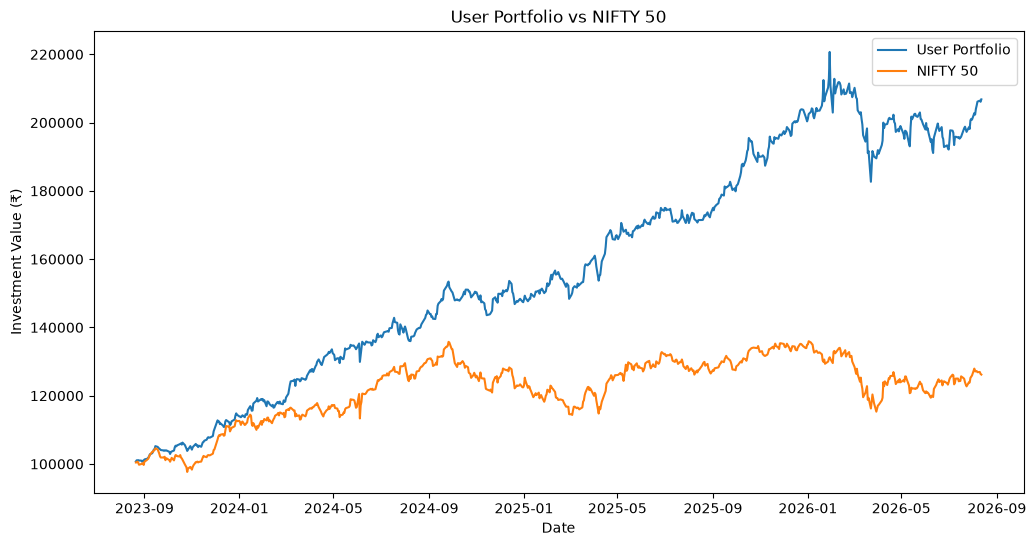

In [180]:
plt.figure(figsize=(12, 6))

plt.plot(
    user_comparison_growth.index,
    user_comparison_growth["Portfolio"],
    label="User Portfolio"
)

plt.plot(
    user_comparison_growth.index,
    user_comparison_growth["NIFTY50"],
    label="NIFTY 50"
)

plt.xlabel("Date")
plt.ylabel("Investment Value (₹)")
plt.title("User Portfolio vs NIFTY 50")

plt.legend()

plt.show()

In [181]:
user_stress_returns = {}

for asset in user_assets:
    
    if "GOLD" in asset.upper():
        user_stress_returns[asset] = 0.10
    else:
        user_stress_returns[asset] = -0.20

user_stress_returns

{'ICICIBANK.NS': -0.2,
 'LT.NS': -0.2,
 'BHARTIARTL.NS': -0.2,
 'TCS.NS': -0.2,
 'GOLDBEES.NS': 0.1}

In [182]:
user_stress_impact = sum(
    user_optimal_weights[i]
    * user_stress_returns[asset]
    for i, asset in enumerate(user_assets)
)

print(
    f"Stress Test Portfolio Impact: "
    f"{user_stress_impact:.2%}"
)

Stress Test Portfolio Impact: -17.00%


In [183]:
user_stress_value = (
    1000000 * (1 + user_stress_impact)
)

print(
    f"Portfolio Value After Stress: "
    f"₹{user_stress_value:,.2f}"
)

Portfolio Value After Stress: ₹830,000.00


In [184]:
def analyze_portfolio(tickers, start_date=None, end_date=None):
    
    print("=" * 70)
    print("              PORTFOLIO ANALYTICS MODEL")
    print("=" * 70)
    
    # --------------------------------------------------
    # 1. DOWNLOAD MARKET DATA
    # --------------------------------------------------
    
    print("\n[1/8] Fetching market data...")
    
    if start_date is None:
        start_date = "2023-01-01"
    
    if end_date is None:
        end_date = None
    
    prices = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )["Close"]
    
    prices = prices.dropna(axis=1, how="all")
    
    valid_tickers = list(prices.columns)
    
    if len(valid_tickers) < 2:
        print("Not enough valid assets.")
        return
    
    print("Assets:", valid_tickers)
    
    # --------------------------------------------------
    # 2. CALCULATE RETURNS
    # --------------------------------------------------
    
    print("\n[2/8] Calculating returns...")
    
    returns = prices.pct_change().dropna()
    
    annual_returns = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)
    covariance = returns.cov() * 252
    
    # --------------------------------------------------
    # 3. PORTFOLIO OPTIMIZATION
    # --------------------------------------------------
    
    print("\n[3/8] Optimizing portfolio...")
    
    n_assets = len(valid_tickers)
    
    expected_returns = annual_returns.values
    
    def portfolio_performance(weights):
        
        portfolio_return = np.dot(
            weights,
            expected_returns
        )
        
        portfolio_volatility = np.sqrt(
            np.dot(
                weights.T,
                np.dot(
                    covariance.values,
                    weights
                )
            )
        )
        
        return portfolio_return, portfolio_volatility
    
    def negative_sharpe(weights):
        
        portfolio_return, portfolio_volatility = (
            portfolio_performance(weights)
        )
        
        return -(
            portfolio_return - risk_free_rate
        ) / portfolio_volatility
    
    initial_weights = np.array(
        [1 / n_assets] * n_assets
    )
    
    bounds = tuple(
        (0.05, 0.40)
        for _ in range(n_assets)
    )
    
    constraints = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }
    
    optimization_result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    if not optimization_result.success:
        print("Optimization failed:")
        print(optimization_result.message)
        return
    
    optimal_weights = optimization_result.x
    
    portfolio_return, portfolio_volatility = (
        portfolio_performance(optimal_weights)
    )
    
    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    # --------------------------------------------------
    # 4. PORTFOLIO DAILY RETURNS
    # --------------------------------------------------
    
    print("\n[4/8] Calculating portfolio risk...")
    
    portfolio_daily_returns = returns.dot(
        optimal_weights
    )
    
    # Maximum Drawdown
    
    portfolio_value = (
        1 + portfolio_daily_returns
    ).cumprod()
    
    running_peak = portfolio_value.cummax()
    
    drawdown = (
        portfolio_value - running_peak
    ) / running_peak
    
    maximum_drawdown = drawdown.min()
    
    # VaR
    
    var_95 = portfolio_daily_returns.quantile(0.05)
    
    # Expected Shortfall
    
    worst_returns = portfolio_daily_returns[
        portfolio_daily_returns <= var_95
    ]
    
    expected_shortfall = worst_returns.mean()
    
    # --------------------------------------------------
    # 5. NIFTY 50 BENCHMARK
    # --------------------------------------------------
    
    print("\n[5/8] Comparing with NIFTY 50...")
    
    benchmark = yf.download(
        "^NSEI",
        start=returns.index.min(),
        end=returns.index.max(),
        auto_adjust=True,
        progress=False
    )["Close"]
    
    benchmark = benchmark.squeeze()
    
    benchmark_returns = (
        benchmark.pct_change()
        .dropna()
    )
    
    comparison = pd.concat(
        [
            portfolio_daily_returns,
            benchmark_returns
        ],
        axis=1,
        join="inner"
    )
    
    comparison.columns = [
        "Portfolio",
        "NIFTY50"
    ]
    
    portfolio_benchmark_return = (
        comparison["Portfolio"].mean() * 252
    )
    
    nifty_return = (
        comparison["NIFTY50"].mean() * 252
    )
    
    beta = (
        comparison["Portfolio"].cov(
            comparison["NIFTY50"]
        )
        /
        comparison["NIFTY50"].var()
    )
    
    alpha = (
        portfolio_benchmark_return
        -
        (
            risk_free_rate
            +
            beta
            * (
                nifty_return
                - risk_free_rate
            )
        )
    )
    
    active_return = (
        portfolio_benchmark_return
        - nifty_return
    )
    
    # --------------------------------------------------
    # 6. STRESS TEST
    # --------------------------------------------------
    
    print("\n[6/8] Running stress test...")
    
    stress_returns = {}
    
    for asset in valid_tickers:
        
        if "GOLD" in asset.upper():
            stress_returns[asset] = 0.10
        else:
            stress_returns[asset] = -0.20
    
    stress_impact = sum(
        optimal_weights[i]
        * stress_returns[asset]
        for i, asset in enumerate(valid_tickers)
    )
    
    # --------------------------------------------------
    # 7. ALLOCATION TABLE
    # --------------------------------------------------
    
    print("\n[7/8] Preparing allocation...")
    
    allocation = pd.DataFrame({
        "Asset": valid_tickers,
        "Optimal Weight (%)":
            optimal_weights * 100,
        "Annual Return (%)":
            annual_returns.values * 100,
        "Annual Volatility (%)":
            annual_volatility.values * 100
    })
    
    # --------------------------------------------------
    # 8. FINAL REPORT
    # --------------------------------------------------
    
    print("\n[8/8] Generating report...")
    
    print("\n" + "=" * 70)
    print("                    FINAL REPORT")
    print("=" * 70)
    
    print("\nPORTFOLIO PERFORMANCE")
    print("-" * 70)
    
    print(
        f"Expected Annual Return : "
        f"{portfolio_return:.2%}"
    )
    
    print(
        f"Annual Volatility      : "
        f"{portfolio_volatility:.2%}"
    )
    
    print(
        f"Sharpe Ratio           : "
        f"{sharpe_ratio:.2f}"
    )
    
    print("\nRISK METRICS")
    print("-" * 70)
    
    print(
        f"Maximum Drawdown       : "
        f"{maximum_drawdown:.2%}"
    )
    
    print(
        f"95% Daily VaR          : "
        f"{var_95:.2%}"
    )
    
    print(
        f"95% Expected Shortfall : "
        f"{expected_shortfall:.2%}"
    )
    
    print("\nBENCHMARK ANALYSIS")
    print("-" * 70)
    
    print(
        f"Portfolio Return       : "
        f"{portfolio_benchmark_return:.2%}"
    )
    
    print(
        f"NIFTY 50 Return        : "
        f"{nifty_return:.2%}"
    )
    
    print(
        f"Beta                   : "
        f"{beta:.2f}"
    )
    
    print(
        f"Alpha                  : "
        f"{alpha:.2%}"
    )
    
    print(
        f"Active Return          : "
        f"{active_return:.2%}"
    )
    
    print("\nSTRESS TEST")
    print("-" * 70)
    
    print(
        f"20% Equity Crash / "
        f"10% Gold Rise: "
        f"{stress_impact:.2%}"
    )
    
    print("\nOPTIMAL ALLOCATION")
    print("-" * 70)
    
    print(
        allocation.to_string(index=False)
    )
    
    print("\n" + "=" * 70)
    print("             ANALYSIS COMPLETED")
    print("=" * 70)
    
    return {
        "prices": prices,
        "returns": returns,
        "allocation": allocation,
        "optimal_weights": optimal_weights,
        "portfolio_return": portfolio_return,
        "portfolio_volatility": portfolio_volatility,
        "sharpe_ratio": sharpe_ratio,
        "maximum_drawdown": maximum_drawdown,
        "var_95": var_95,
        "expected_shortfall": expected_shortfall,
        "beta": beta,
        "alpha": alpha,
        "active_return": active_return,
        "stress_impact": stress_impact,
        "comparison": comparison
    }

In [185]:
my_portfolio = [
    "RELIANCE.NS",
    "HDFCBANK.NS",
    "TCS.NS",
    "INFY.NS",
    "GOLDBEES.NS"
]

result = analyze_portfolio(my_portfolio)

              PORTFOLIO ANALYTICS MODEL

[1/8] Fetching market data...
Assets: ['GOLDBEES.NS', 'HDFCBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS']

[2/8] Calculating returns...

[3/8] Optimizing portfolio...

[4/8] Calculating portfolio risk...

[5/8] Comparing with NIFTY 50...

[6/8] Running stress test...

[7/8] Preparing allocation...

[8/8] Generating report...

                    FINAL REPORT

PORTFOLIO PERFORMANCE
----------------------------------------------------------------------
Expected Annual Return : 13.81%
Annual Volatility      : 13.19%
Sharpe Ratio           : 0.55

RISK METRICS
----------------------------------------------------------------------
Maximum Drawdown       : -15.56%
95% Daily VaR          : -1.23%
95% Expected Shortfall : -1.96%

BENCHMARK ANALYSIS
----------------------------------------------------------------------
Portfolio Return       : 14.03%
NIFTY 50 Return        : 9.06%
Beta                   : 0.72
Alpha                  : 5.67%
Active Return 

In [186]:
my_portfolio = [
    "RELIANCE.NS",
    "HDFCBANK.NS",
    "TCS.NS",
    "INFY.NS",
    "GOLDBEES.NS"
]

result = analyze_portfolio(my_portfolio)

              PORTFOLIO ANALYTICS MODEL

[1/8] Fetching market data...
Assets: ['GOLDBEES.NS', 'HDFCBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS']

[2/8] Calculating returns...

[3/8] Optimizing portfolio...

[4/8] Calculating portfolio risk...

[5/8] Comparing with NIFTY 50...

[6/8] Running stress test...

[7/8] Preparing allocation...

[8/8] Generating report...

                    FINAL REPORT

PORTFOLIO PERFORMANCE
----------------------------------------------------------------------
Expected Annual Return : 13.81%
Annual Volatility      : 13.19%
Sharpe Ratio           : 0.55

RISK METRICS
----------------------------------------------------------------------
Maximum Drawdown       : -15.56%
95% Daily VaR          : -1.23%
95% Expected Shortfall : -1.96%

BENCHMARK ANALYSIS
----------------------------------------------------------------------
Portfolio Return       : 14.03%
NIFTY 50 Return        : 9.06%
Beta                   : 0.72
Alpha                  : 5.67%
Active Return 

In [187]:
def portfolio_dashboard(result):

    allocation = result["allocation"]
    comparison = result["comparison"]

    # -----------------------------
    # 1. OPTIMAL ALLOCATION
    # -----------------------------

    plt.figure(figsize=(10, 6))

    plt.bar(
        allocation["Asset"],
        allocation["Optimal Weight (%)"]
    )

    plt.xlabel("Asset")
    plt.ylabel("Optimal Weight (%)")
    plt.title("Optimal Portfolio Allocation")

    plt.xticks(rotation=20)

    plt.show()


    # -----------------------------
    # 2. PORTFOLIO VS NIFTY 50
    # -----------------------------

    growth = (
        1 + comparison
    ).cumprod() * 100000

    plt.figure(figsize=(12, 6))

    plt.plot(
        growth.index,
        growth["Portfolio"],
        label="Optimized Portfolio"
    )

    plt.plot(
        growth.index,
        growth["NIFTY50"],
        label="NIFTY 50"
    )

    plt.xlabel("Date")
    plt.ylabel("Investment Value (₹)")
    plt.title("Portfolio vs NIFTY 50")

    plt.legend()

    plt.show()


    # -----------------------------
    # 3. DRAWDOWN
    # -----------------------------

    portfolio_returns = comparison["Portfolio"]

    portfolio_value = (
        1 + portfolio_returns
    ).cumprod()

    running_peak = (
        portfolio_value.cummax()
    )

    drawdown = (
        portfolio_value - running_peak
    ) / running_peak

    plt.figure(figsize=(12, 6))

    plt.plot(
        drawdown.index,
        drawdown * 100
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel("Date")
    plt.ylabel("Drawdown (%)")
    plt.title("Portfolio Drawdown")

    plt.show()


    # -----------------------------
    # 4. RISK VS RETURN
    # -----------------------------

    plt.figure(figsize=(10, 6))

    plt.scatter(
        allocation["Annual Volatility (%)"],
        allocation["Annual Return (%)"],
        s=100
    )

    for i in range(len(allocation)):

        asset = allocation.iloc[i]["Asset"]

        x = allocation.iloc[i][
            "Annual Volatility (%)"
        ]

        y = allocation.iloc[i][
            "Annual Return (%)"
        ]

        plt.annotate(
            asset,
            (x, y)
        )

    plt.xlabel("Annual Volatility (%)")
    plt.ylabel("Annual Return (%)")

    plt.title(
        "Asset Risk-Return Profile"
    )

    plt.show()

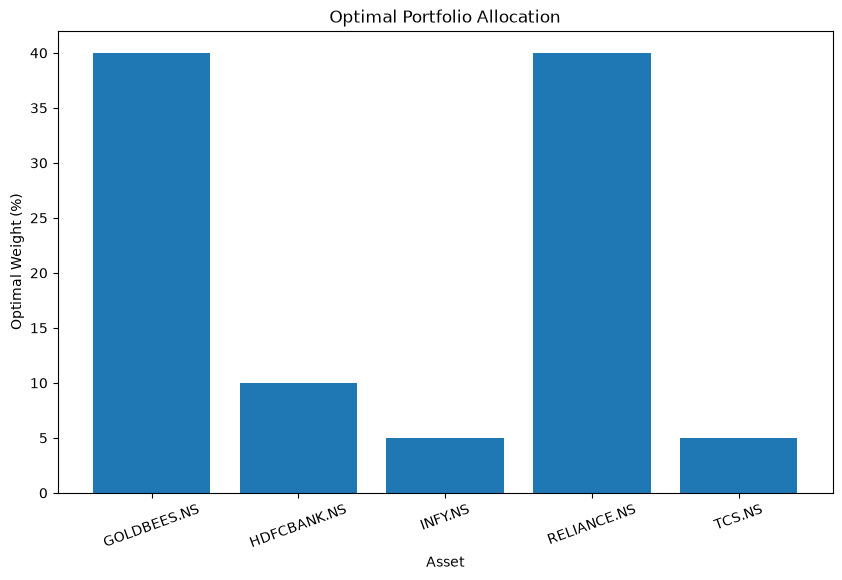

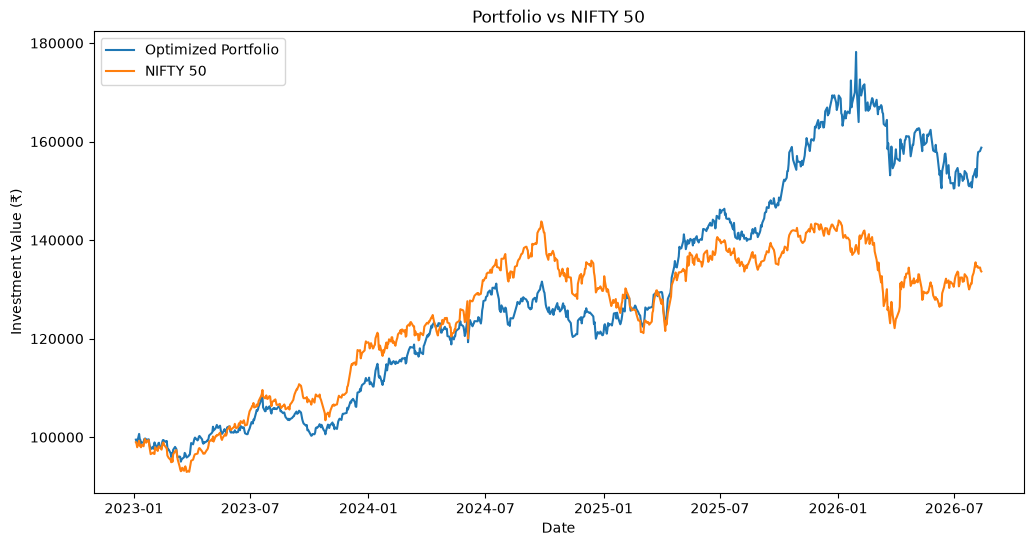

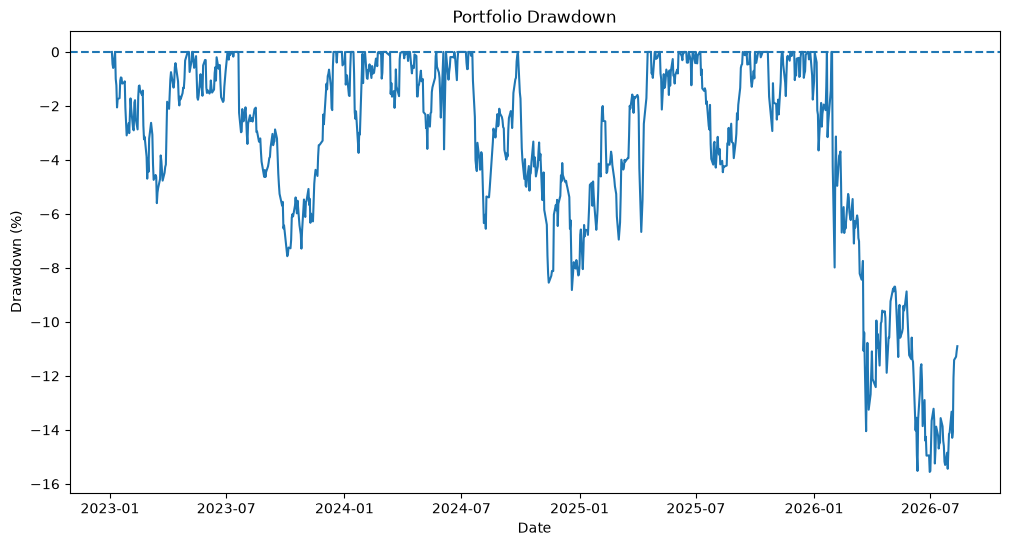

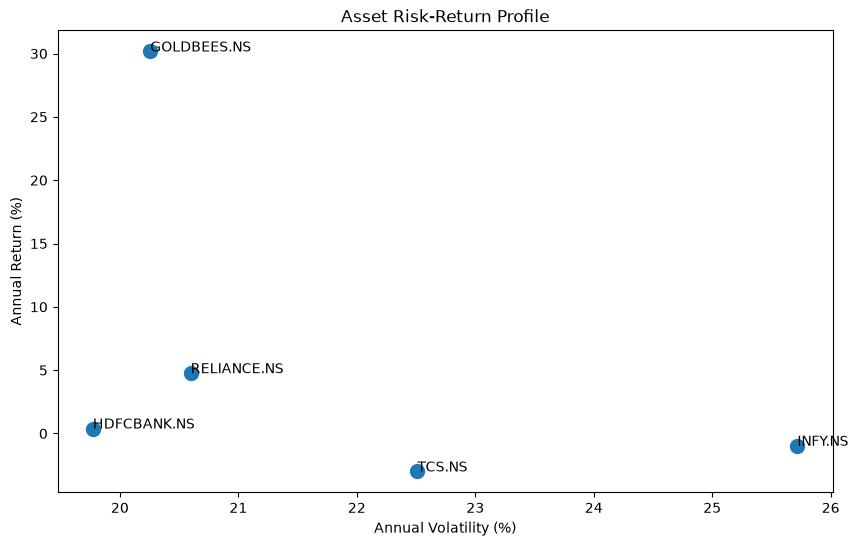

In [188]:
portfolio_dashboard(result)

In [189]:
def run_full_analysis(tickers):
    
    result = analyze_portfolio(tickers)
    
    if result is not None:
        portfolio_dashboard(result)
    
    return result

              PORTFOLIO ANALYTICS MODEL

[1/8] Fetching market data...
Assets: ['GOLDBEES.NS', 'HDFCBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS']

[2/8] Calculating returns...

[3/8] Optimizing portfolio...

[4/8] Calculating portfolio risk...

[5/8] Comparing with NIFTY 50...

[6/8] Running stress test...

[7/8] Preparing allocation...

[8/8] Generating report...

                    FINAL REPORT

PORTFOLIO PERFORMANCE
----------------------------------------------------------------------
Expected Annual Return : 13.81%
Annual Volatility      : 13.19%
Sharpe Ratio           : 0.55

RISK METRICS
----------------------------------------------------------------------
Maximum Drawdown       : -15.56%
95% Daily VaR          : -1.23%
95% Expected Shortfall : -1.96%

BENCHMARK ANALYSIS
----------------------------------------------------------------------
Portfolio Return       : 14.03%
NIFTY 50 Return        : 9.06%
Beta                   : 0.72
Alpha                  : 5.67%
Active Return 

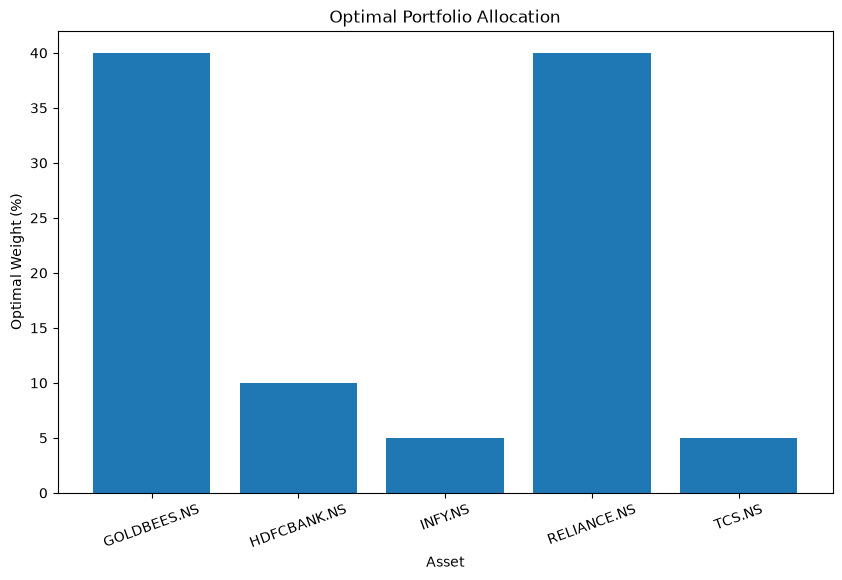

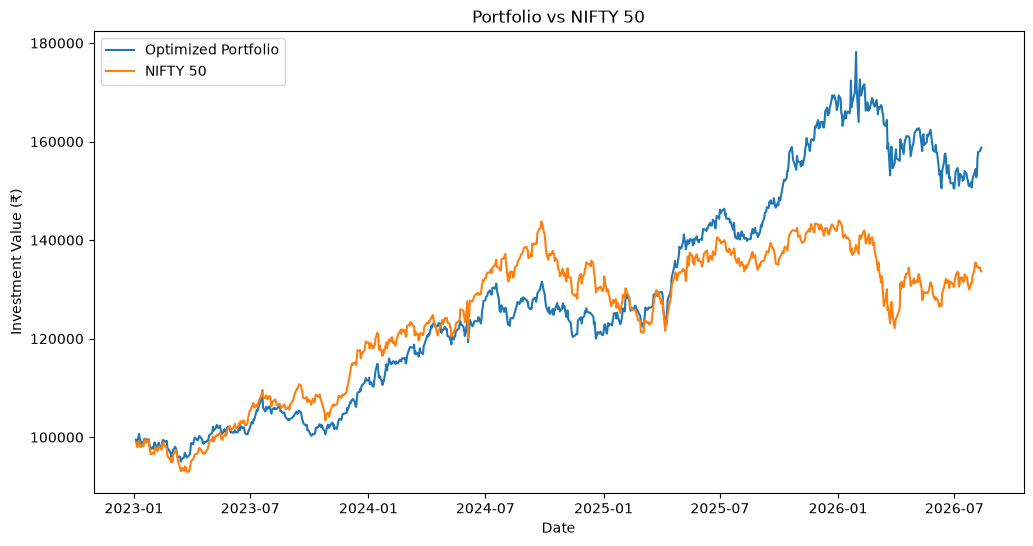

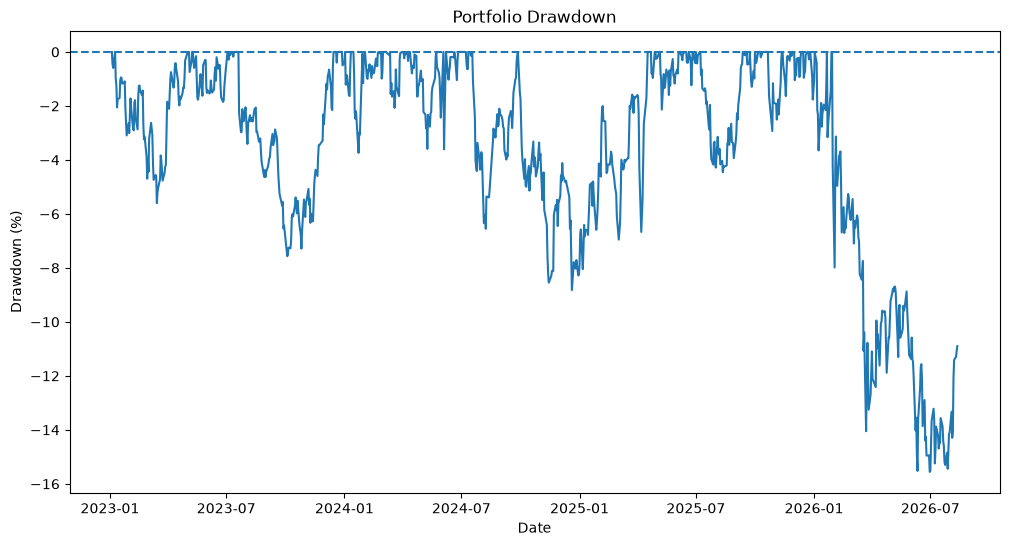

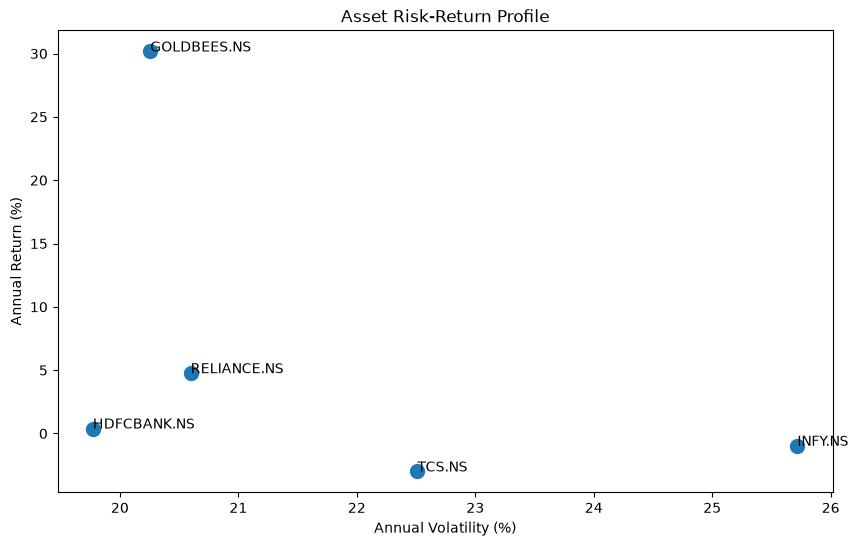

In [190]:
my_portfolio = [
    "RELIANCE.NS",
    "HDFCBANK.NS",
    "TCS.NS",
    "INFY.NS",
    "GOLDBEES.NS"
]

result = run_full_analysis(my_portfolio)